# GLM Algorithm Arena — Phase 2: 20 Real Datasets

Benchmarking of **all GLM solvers** across **20 real-world datasets** with a
comprehensive hyperparameter grid.  Each *(solver, config)* pair produces one
point in the embedding space.  t-SNE and UMAP projections (one figure per
dataset) reveal how algorithmically similar the estimated solutions are across
solver families.


## Section 0 — Setup

In [1]:
import sys, os, time, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes, fetch_california_housing, load_breast_cancer
from sklearn.datasets import fetch_openml
from sklearn.manifold import TSNE
import sklearn
import umap

print(f"sklearn  {sklearn.__version__}")
print(f"umap     {umap.__version__}")

# TSNE param name changed in sklearn 1.5 (max_iter replaces n_iter)
_sk_ver = tuple(int(x) for x in sklearn.__version__.split('.')[:2])
_TSNE_ITER_KW = 'max_iter' if _sk_ver >= (1, 5) else 'n_iter'

# ── Solver imports ────────────────────────────────────────────────────────────
from src.glmzoo.solvers.classical.ols           import OLSSolver
from src.glmzoo.solvers.classical.ridge         import RidgeSolver
from src.glmzoo.solvers.classical.glm_irls      import GLMIRLSSolver
from src.glmzoo.solvers.penalized.lasso_cd      import LassoCDSolver
from src.glmzoo.solvers.penalized.elastic_net   import ElasticNetSolver
from src.glmzoo.solvers.penalized.adaptive_lasso import AdaptiveLassoSolver
from src.glmzoo.solvers.penalized.scad_lla      import SCADLLASolver
from src.glmzoo.solvers.penalized.mcp_cd        import MCPCDSolver
from src.glmzoo.solvers.penalized.group_lasso   import GroupLassoSolver
from src.glmzoo.solvers.penalized.fused_lasso   import FusedLassoSolver
from src.glmzoo.solvers.path.lars               import LARSSolver
from src.glmzoo.solvers.first_order.ista        import ISTASolver
from src.glmzoo.solvers.first_order.fista       import FISTASolver
from src.glmzoo.solvers.online.sgd              import SGDSolver
from src.glmzoo.solvers.online.implicit_sgd     import ImplicitSGDSolver
from src.glmzoo.solvers.online.adagrad          import AdaGradSolver
from src.glmzoo.solvers.online.fobos            import FOBOSSolver
from src.glmzoo.solvers.online.rda              import RDASolver
from src.glmzoo.solvers.online.truncated_gradient import TruncatedGradientSolver
from src.glmzoo.solvers.online.renewable_glm   import RenewableGLMSolver

print("All solver classes imported.")

FAMILY = {
    OLSSolver: "Classical",      GLMIRLSSolver: "Classical",   LARSSolver: "Classical",
    RidgeSolver: "Penalized",    LassoCDSolver: "Penalized",   ElasticNetSolver: "Penalized",
    ISTASolver: "First-order",   FISTASolver: "First-order",
    AdaptiveLassoSolver: "Penalized", SCADLLASolver: "Penalized", MCPCDSolver: "Penalized",
    GroupLassoSolver: "Penalized",    FusedLassoSolver: "Penalized",
    SGDSolver: "Online",         ImplicitSGDSolver: "Online",  AdaGradSolver: "Online",
    FOBOSSolver: "Online",       RDASolver: "Online",          TruncatedGradientSolver: "Online",
    RenewableGLMSolver: "Online",
}

FAMILY_COLORS = {
    "Classical":   "#1f77b4",
    "Penalized":   "#2ca02c",
    "First-order": "#ff7f0e",
    "Online":      "#d62728",
}


sklearn  1.8.0
umap     0.5.12
All solver classes imported.


## Section 1 — Load Real Datasets

In [2]:
RNG  = np.random.default_rng(42)
MAX_N = 2000          # subsample cap to keep runtimes sane
datasets = {}

# ── helpers ──────────────────────────────────────────────────────────────────
def _add_regression(X, y, name):
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)
    ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X, y = X[ok], y[ok]
    if len(X) < 40:
        print(f"  SKIP {name}: only {len(X)} valid rows"); return
    if len(X) > MAX_N:
        idx = RNG.choice(len(X), MAX_N, replace=False)
        X, y = X[idx], y[idx]
    X = StandardScaler().fit_transform(X)
    y = (y - y.mean()) / (y.std() + 1e-12)
    datasets[name] = dict(X=X, y=y, link="identity", kind="regression")
    print(f"  [R] {name:30s}  n={X.shape[0]:4d}  p={X.shape[1]}")

def _add_logistic(X, y, name):
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)
    ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X, y = X[ok], y[ok]
    if len(X) < 40:
        print(f"  SKIP {name}: only {len(X)} valid rows"); return
    if len(X) > MAX_N:
        idx = RNG.choice(len(X), MAX_N, replace=False)
        X, y = X[idx], y[idx]
    X = StandardScaler().fit_transform(X)
    datasets[name] = dict(X=X, y=y, link="logit", kind="logistic")
    print(f"  [L] {name:30s}  n={X.shape[0]:4d}  p={X.shape[1]}")

def _oml(data_id, name, kind, binarize=False):
    try:
        bunch = fetch_openml(data_id=data_id, as_frame=True, parser='auto')
        Xdf = bunch.data.select_dtypes(include=[np.number])
        ys   = pd.to_numeric(bunch.target, errors='coerce')
        if ys.isna().all():                          # categorical target
            ys = bunch.target.astype('category').cat.codes.astype(float)
        valid = Xdf.index.intersection(ys.dropna().index)
        Xdf   = Xdf.loc[valid].dropna()
        ys    = ys.loc[Xdf.index]
        X, y  = Xdf.values, ys.values
        if kind == "logit":
            uniq = np.unique(y[np.isfinite(y)])
            if len(uniq) != 2 or binarize:
                y = (y > np.nanmedian(y)).astype(float)
            else:
                y = (y != uniq.min()).astype(float)
            _add_logistic(X, y, name)
        else:
            _add_regression(X, y, name)
    except Exception as e:
        print(f"  WARN: {name} (id={data_id}): {type(e).__name__}: {str(e)[:70]}")

# ── sklearn built-ins (always available) ─────────────────────────────────────
print("sklearn built-ins:")
raw = load_diabetes()
_add_regression(raw.data, raw.target, "Diabetes")

raw = fetch_california_housing()
_add_regression(raw.data, raw.target, "CA Housing")

raw = load_breast_cancer()
_add_logistic(raw.data, raw.target.astype(float), "Breast Cancer")

# ── OpenML regression ─────────────────────────────────────────────────────────
print("\nOpenML regression:")
_oml(4353,  "Concrete Strength",   "identity")
_oml(242,   "Energy Efficiency",   "identity")
_oml(183,   "Abalone",             "identity")
_oml(40691, "Wine Quality Red",    "identity")
_oml(41519, "Airfoil Noise",       "identity")
_oml(196,   "Auto MPG",            "identity")
_oml(243,   "Yacht Hydro",         "identity")
_oml(560,   "Body Fat",            "identity")
_oml(507,   "Wind Power",          "identity")
_oml(617,   "Bodyfat2",            "identity")   # fallback if 560 fails
_oml(308,   "PBC Liver",           "identity")
_oml(41021, "Moneyball",           "identity")

# ── OpenML logistic ───────────────────────────────────────────────────────────
print("\nOpenML logistic:")
_oml(37,    "Pima Diabetes",       "logit")
_oml(59,    "Ionosphere",          "logit")
_oml(1462,  "Banknote Auth",       "logit")
_oml(44,    "Spambase",            "logit")
_oml(31,    "German Credit",       "logit",  binarize=True)
_oml(40,    "Sonar",               "logit")
_oml(29,    "Credit Approval",     "logit")
_oml(1067,  "KC1 Defects",         "logit")
_oml(1464,  "Blood Transfusion",   "logit")
_oml(1480,  "Indian Liver",        "logit")
_oml(40945, "Titanic",             "logit")
_oml(1494,  "Mammography",         "logit")

print(f"\n{'='*55}")
print(f"Datasets loaded: {len(datasets)}")
for nm, ds in datasets.items():
    print(f"  {ds['kind'][0].upper()} {nm}: n={ds['X'].shape[0]}, p={ds['X'].shape[1]}")


sklearn built-ins:
  [R] Diabetes                        n= 442  p=10
  [R] CA Housing                      n=2000  p=8
  [L] Breast Cancer                   n= 569  p=30

OpenML regression:
  WARN: Concrete Strength (id=4353): AttributeError: 'numpy.float64' object has no attribute 'isna'


  WARN: Energy Efficiency (id=242): OpenMLError: Dataset with data_id 242 not found.
  [R] Abalone                         n=2000  p=7
  [R] Wine Quality Red                n=1599  p=11
  [R] Airfoil Noise                   n= 442  p=10
  [R] Auto MPG                        n= 392  p=4


  WARN: Yacht Hydro (id=243): OpenMLError: Dataset with data_id 243 not found.


  [R] Body Fat                        n= 252  p=14


  [R] Wind Power                      n=2000  p=6


...

  [L] KC1 Defects                     n=2000  p=21


  [L] Blood Transfusion               n= 748  p=4


  [L] Indian Liver                    n= 583  p=9


  [L] Titanic                         n= 119  p=6


  [L] Mammography                     n=1055  p=41

Datasets loaded: 24
  R Diabetes: n=442, p=10
  R CA Housing: n=2000, p=8
  L Breast Cancer: n=569, p=30
  R Abalone: n=2000, p=7
  R Wine Quality Red: n=1599, p=11
  R Airfoil Noise: n=442, p=10
  R Auto MPG: n=392, p=4
  R Body Fat: n=252, p=14
  R Wind Power: n=2000, p=6
  R Bodyfat2: n=500, p=5
  R PBC Liver: n=2000, p=32
  R Moneyball: n=420, p=8
  L Pima Diabetes: n=768, p=8
  L Ionosphere: n=351, p=34
  L Banknote Auth: n=1372, p=4
  L Spambase: n=2000, p=57
  L German Credit: n=1000, p=7
  L Sonar: n=208, p=60
  L Credit Approval: n=666, p=6
  L KC1 Defects: n=2000, p=21
  L Blood Transfusion: n=748, p=4
  L Indian Liver: n=583, p=9
  L Titanic: n=119, p=6
  L Mammography: n=1055, p=41


## Section 2 — Hyperparameter Grid

In [3]:
SOLVER_CONFIGS = []   # list of (SolverClass, config_dict, short_label)

# ── Classical (no tuning) ─────────────────────────────────────────────────────
SOLVER_CONFIGS += [
    (OLSSolver,     {}, "OLS"),
    (GLMIRLSSolver, {}, "IRLS"),
    (LARSSolver,    {}, "LARS"),       # regression only
]

# ── Ridge ─────────────────────────────────────────────────────────────────────
for _lam in [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]:
    SOLVER_CONFIGS.append((RidgeSolver, {"lam": _lam}, f"Ridge λ={_lam}"))

# ── Lasso-CD ──────────────────────────────────────────────────────────────────
for _lam in [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]:
    SOLVER_CONFIGS.append((LassoCDSolver, {"lam": _lam}, f"Lasso λ={_lam}"))

# ── Elastic Net ───────────────────────────────────────────────────────────────
for _lam in [0.01, 0.05, 0.1, 0.5]:
    for _a in [0.1, 0.3, 0.5, 0.7, 0.9]:
        SOLVER_CONFIGS.append((ElasticNetSolver, {"lam": _lam, "alpha": _a},
                               f"EN λ={_lam} α={_a}"))

# ── ISTA / FISTA ──────────────────────────────────────────────────────────────
for _lam in [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]:
    SOLVER_CONFIGS.append((ISTASolver,  {"lam": _lam}, f"ISTA λ={_lam}"))
    SOLVER_CONFIGS.append((FISTASolver, {"lam": _lam}, f"FISTA λ={_lam}"))

# ── Adaptive Lasso ────────────────────────────────────────────────────────────
for _lam in [0.005, 0.01, 0.05, 0.1, 0.5, 1.0]:
    SOLVER_CONFIGS.append((AdaptiveLassoSolver, {"lam": _lam}, f"AdaLasso λ={_lam}"))

# ── SCAD ──────────────────────────────────────────────────────────────────────
for _lam in [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]:
    SOLVER_CONFIGS.append((SCADLLASolver, {"lam": _lam}, f"SCAD λ={_lam}"))

# ── MCP ───────────────────────────────────────────────────────────────────────
for _lam in [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]:
    SOLVER_CONFIGS.append((MCPCDSolver, {"lam": _lam}, f"MCP λ={_lam}"))

# ── Group Lasso (n_groups injected per dataset) ───────────────────────────────
for _lam in [0.01, 0.05, 0.1, 0.5, 1.0]:
    SOLVER_CONFIGS.append((GroupLassoSolver, {"lam": _lam}, f"GroupLasso λ={_lam}"))

# ── Fused Lasso (regression only) ────────────────────────────────────────────
for _l1, _l2 in [(0.01,0.01),(0.05,0.05),(0.1,0.1),(0.1,0.01),(0.01,0.1),(0.5,0.1),(0.1,0.5)]:
    SOLVER_CONFIGS.append((FusedLassoSolver, {"lam1": _l1, "lam2": _l2},
                           f"Fused λ1={_l1} λ2={_l2}"))

# ── SGD ───────────────────────────────────────────────────────────────────────
for _g in [0.005, 0.01, 0.05, 0.1, 0.5]:
    for _T in [5, 10, 20]:
        SOLVER_CONFIGS.append((SGDSolver, {"gamma0": _g, "n_passes": _T},
                               f"SGD γ={_g} T={_T}"))

# ── Implicit SGD ──────────────────────────────────────────────────────────────
for _g in [0.005, 0.01, 0.05, 0.1, 0.5]:
    for _T in [5, 10, 20]:
        SOLVER_CONFIGS.append((ImplicitSGDSolver, {"gamma0": _g, "n_passes": _T},
                               f"ISGD γ={_g} T={_T}"))

# ── AdaGrad ───────────────────────────────────────────────────────────────────
for _eta in [0.01, 0.05, 0.1, 0.5, 1.0]:
    for _T in [5, 10, 20]:
        SOLVER_CONFIGS.append((AdaGradSolver, {"eta": _eta, "n_passes": _T},
                               f"AdaGrad η={_eta} T={_T}"))

# ── FOBOS ─────────────────────────────────────────────────────────────────────
for _lam in [0.01, 0.05, 0.1]:
    for _g in [0.05, 0.1, 0.5]:
        for _T in [5, 10, 20]:
            SOLVER_CONFIGS.append((FOBOSSolver,
                                   {"lam": _lam, "gamma0": _g, "n_passes": _T},
                                   f"FOBOS λ={_lam} γ={_g} T={_T}"))

# ── RDA ───────────────────────────────────────────────────────────────────────
for _lam in [0.01, 0.05, 0.1, 0.3]:
    for _g in [0.05, 0.1, 0.5]:
        SOLVER_CONFIGS.append((RDASolver,
                               {"lam": _lam, "gamma0": _g, "n_passes": 5},
                               f"RDA λ={_lam} γ={_g}"))

# ── Truncated Gradient ────────────────────────────────────────────────────────
for _lam in [0.01, 0.05, 0.1]:
    for _g in [0.05, 0.1, 0.5]:
        for _T in [5, 10, 20]:
            SOLVER_CONFIGS.append((TruncatedGradientSolver,
                                   {"lam": _lam, "gamma0": _g, "n_passes": _T},
                                   f"TruncGrad λ={_lam} γ={_g} T={_T}"))

# ── Renewable GLM ─────────────────────────────────────────────────────────────
for _B in [5, 10, 20]:
    SOLVER_CONFIGS.append((RenewableGLMSolver, {"n_batches": _B},
                           f"Renewable B={_B}"))

print(f"Total solver configurations: {len(SOLVER_CONFIGS)}")


Total solver configurations: 202


## Section 3 — Run Arena

In [4]:
SKIP_FOR_LOGISTIC = {LARSSolver, FusedLassoSolver}
records = []
t_arena = time.time()

for di, (ds_name, ds) in enumerate(datasets.items()):
    X, y, link, kind = ds['X'], ds['y'], ds['link'], ds['kind']
    n, p = X.shape
    t0 = time.time()
    n_ok = 0
    for SolverCls, cfg, label in SOLVER_CONFIGS:
        if kind == "logistic" and SolverCls in SKIP_FOR_LOGISTIC:
            continue
        run_cfg = dict(cfg)
        if SolverCls is GroupLassoSolver:
            run_cfg['n_groups'] = min(5, max(2, p // 5))
        try:
            res  = SolverCls(config=run_cfg).fit(X, y, link=link)
            beta = res.beta_hat
            if not np.all(np.isfinite(beta)):
                raise ValueError("non-finite")
            records.append(dict(
                dataset=ds_name, kind=kind, label=label,
                cls=SolverCls.__name__, family=FAMILY[SolverCls],
                beta=beta.copy(), bnorm=float(np.linalg.norm(beta)),
                ok=True, p=p,
            ))
            n_ok += 1
        except Exception:
            records.append(dict(
                dataset=ds_name, kind=kind, label=label,
                cls=SolverCls.__name__, family=FAMILY.get(SolverCls, '?'),
                beta=None, bnorm=np.nan, ok=False, p=p,
            ))
    print(f"[{di+1:2d}/{len(datasets)}] {ds_name:28s}  n={n:4d} p={p:3d}  "
          f"ok={n_ok:3d}  {time.time()-t0:.1f}s")

df_all = pd.DataFrame(records)
print(f"\nArena done in {time.time()-t_arena:.1f}s")
print(f"Total: {len(df_all)}  |  OK: {df_all.ok.sum()} ({100*df_all.ok.mean():.1f}%)")


[ 1/24] Diabetes                      n= 442 p= 10  ok=202  2.2s


OLS is defined for the identity link; performing one Newton step as an approximation for link='logit'.


RidgeSolver closed form is for the identity link; falling back to Gaussian (identity) fit for link='logit'.


RidgeSolver closed form is for the identity link; falling back to Gaussian (identity) fit for link='logit'.


RidgeSolver closed form is for the identity link; falling back to Gaussian (identity) fit for link='logit'.


...

GroupLassoSolver uses Gaussian fit for link='logit'.


GroupLassoSolver uses Gaussian fit for link='logit'.


GroupLassoSolver uses Gaussian fit for link='logit'.


GroupLassoSolver uses Gaussian fit for link='logit'.


[24/24] Mammography                   n=1055 p= 41  ok=194  5.8s

Arena done in 112.4s
Total: 4744  |  OK: 4688 (98.8%)


## Section 4 — Results Summary

In [5]:
print(df_all.groupby(['dataset','ok']).size().unstack(fill_value=0).to_string())
print()
print(df_all.groupby(['family','ok']).size().unstack(fill_value=0).to_string())


ok                 False  True 
dataset                        
Abalone                0    202
Airfoil Noise          0    202
Auto MPG               0    202
Banknote Auth          0    194
Blood Transfusion      0    194
Body Fat               0    202
Bodyfat2               0    202
Breast Cancer          0    194
CA Housing             0    202
Credit Approval        0    194
Diabetes               0    202
German Credit         28    166
Indian Liver           0    194
Ionosphere             0    194
KC1 Defects            0    194
Mammography            0    194
Moneyball              0    202
PBC Liver              0    202
Pima Diabetes          0    194
Sonar                  0    194
Spambase               0    194
Titanic               28    166
Wind Power             0    202
Wine Quality Red       0    202

ok           False  True 
family                   
Classical        0     59
First-order      0    384
Online           0   2736
Penalized       56   1509


## Section 5 — Outlier Filtering (5× median norm)

In [6]:
def filter_outliers(df, thresh=5.0):
    parts = []
    for ds_name in df['dataset'].unique():
        g = df[(df['dataset'] == ds_name) & df['ok']].copy()
        if len(g) == 0:
            continue
        med = g['bnorm'].median()
        if med == 0:
            med = 1.0
        mask  = g['bnorm'] <= thresh * med
        n_out = (~mask).sum()
        if n_out:
            print(f"  {ds_name}: {n_out} outliers removed (cutoff = {thresh*med:.3f})")
        parts.append(g[mask])
    return pd.concat(parts, ignore_index=True)

df_clean = filter_outliers(df_all)
print(f"\nClean runs: {len(df_clean)}  across {df_clean['dataset'].nunique()} datasets")


  CA Housing: 3 outliers removed (cutoff = 2.976)
  Breast Cancer: 20 outliers removed (cutoff = 3.464)
  Abalone: 2 outliers removed (cutoff = 2.143)
  Wind Power: 16 outliers removed (cutoff = 2.184)
  Ionosphere: 4 outliers removed (cutoff = 3.310)
  Banknote Auth: 4 outliers removed (cutoff = 6.244)
  Spambase: 34 outliers removed (cutoff = 2.545)
  German Credit: 3 outliers removed (cutoff = 0.038)
  Sonar: 20 outliers removed (cutoff = 1.974)
  Credit Approval: 4 outliers removed (cutoff = 2.513)
  KC1 Defects: 61 outliers removed (cutoff = 0.499)
  Blood Transfusion: 50 outliers removed (cutoff = 0.382)
  Indian Liver: 70 outliers removed (cutoff = 0.195)
  Titanic: 18 outliers removed (cutoff = 0.040)
  Mammography: 20 outliers removed (cutoff = 1.767)

Clean runs: 4359  across 24 datasets


## Section 6 — Per-Dataset Embeddings: t-SNE and UMAP

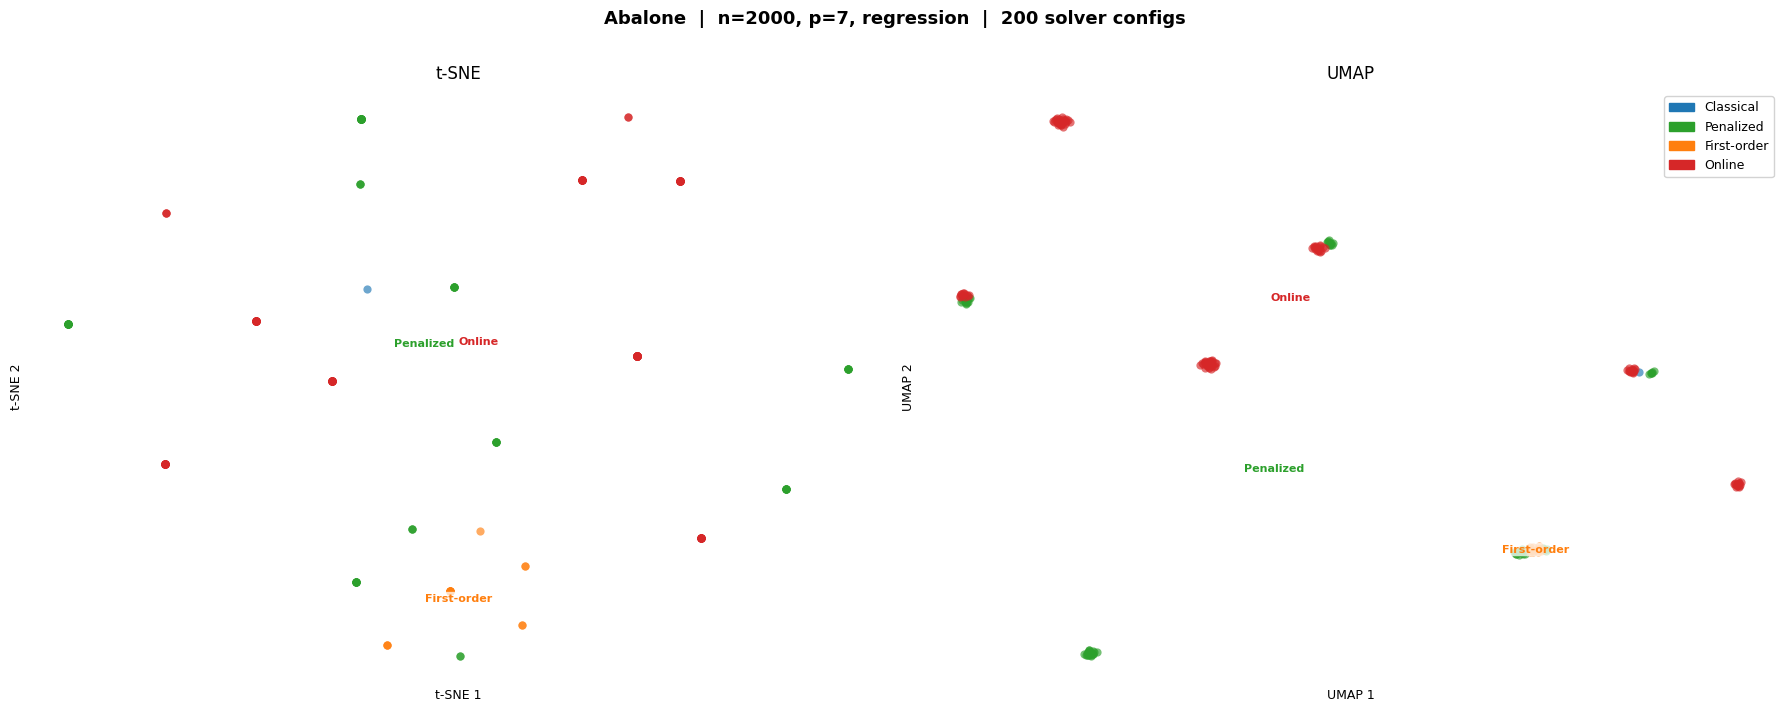

  Saved: fig_embed_Abalone.png


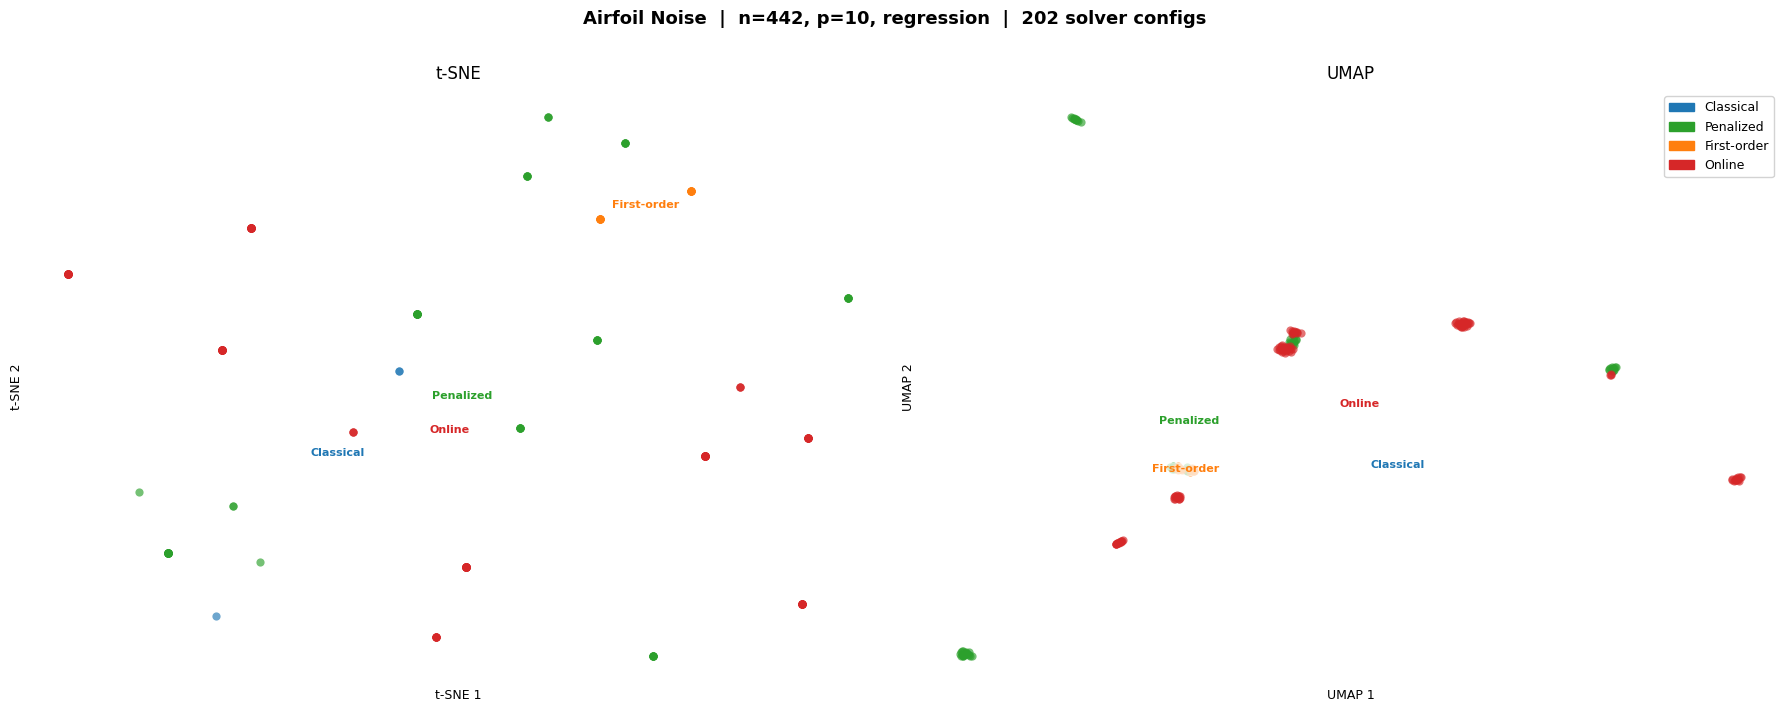

  Saved: fig_embed_Airfoil_Noise.png


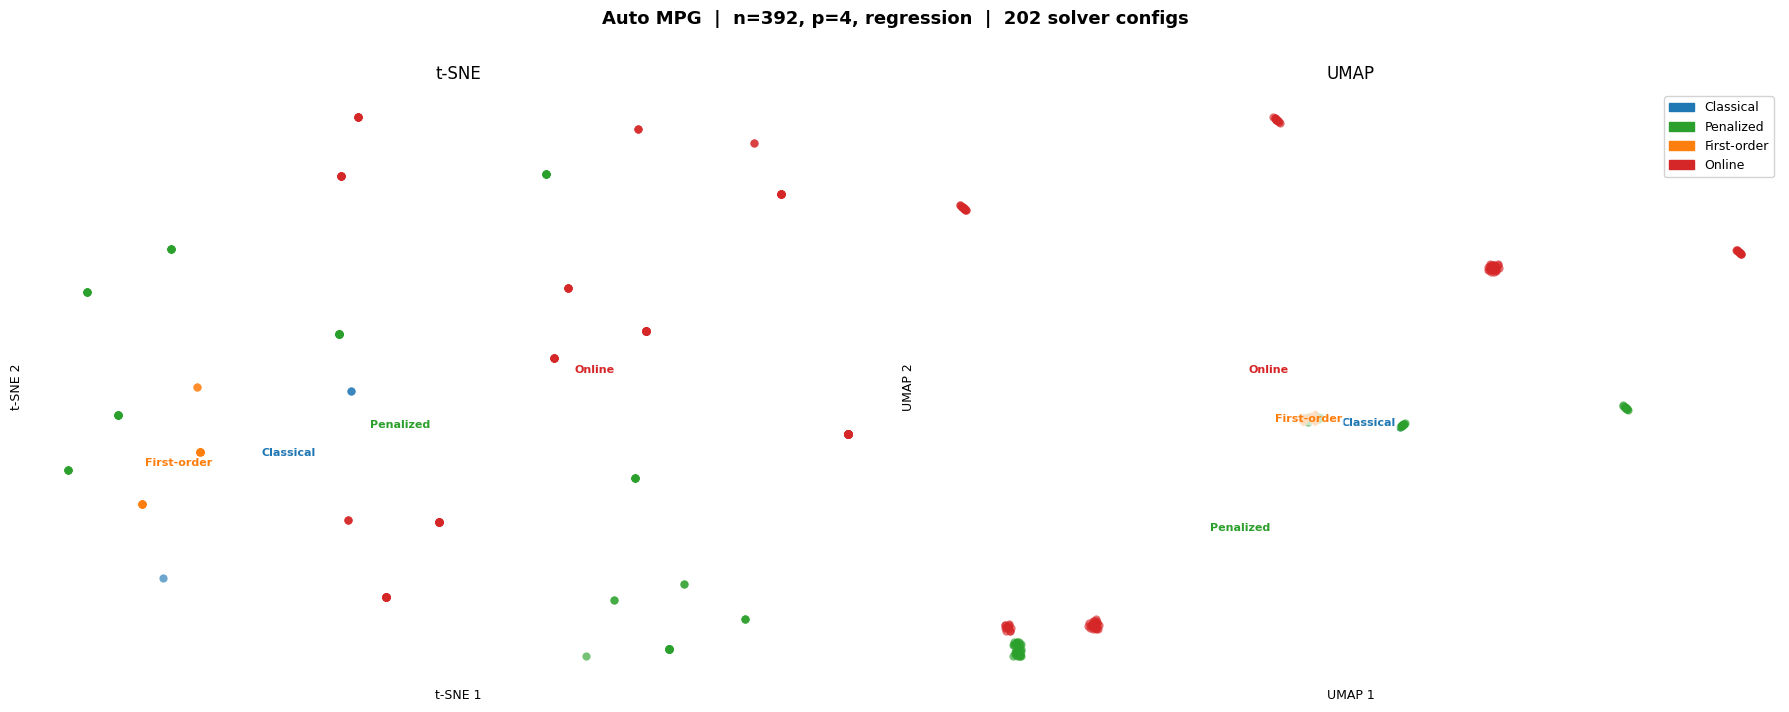

  Saved: fig_embed_Auto_MPG.png


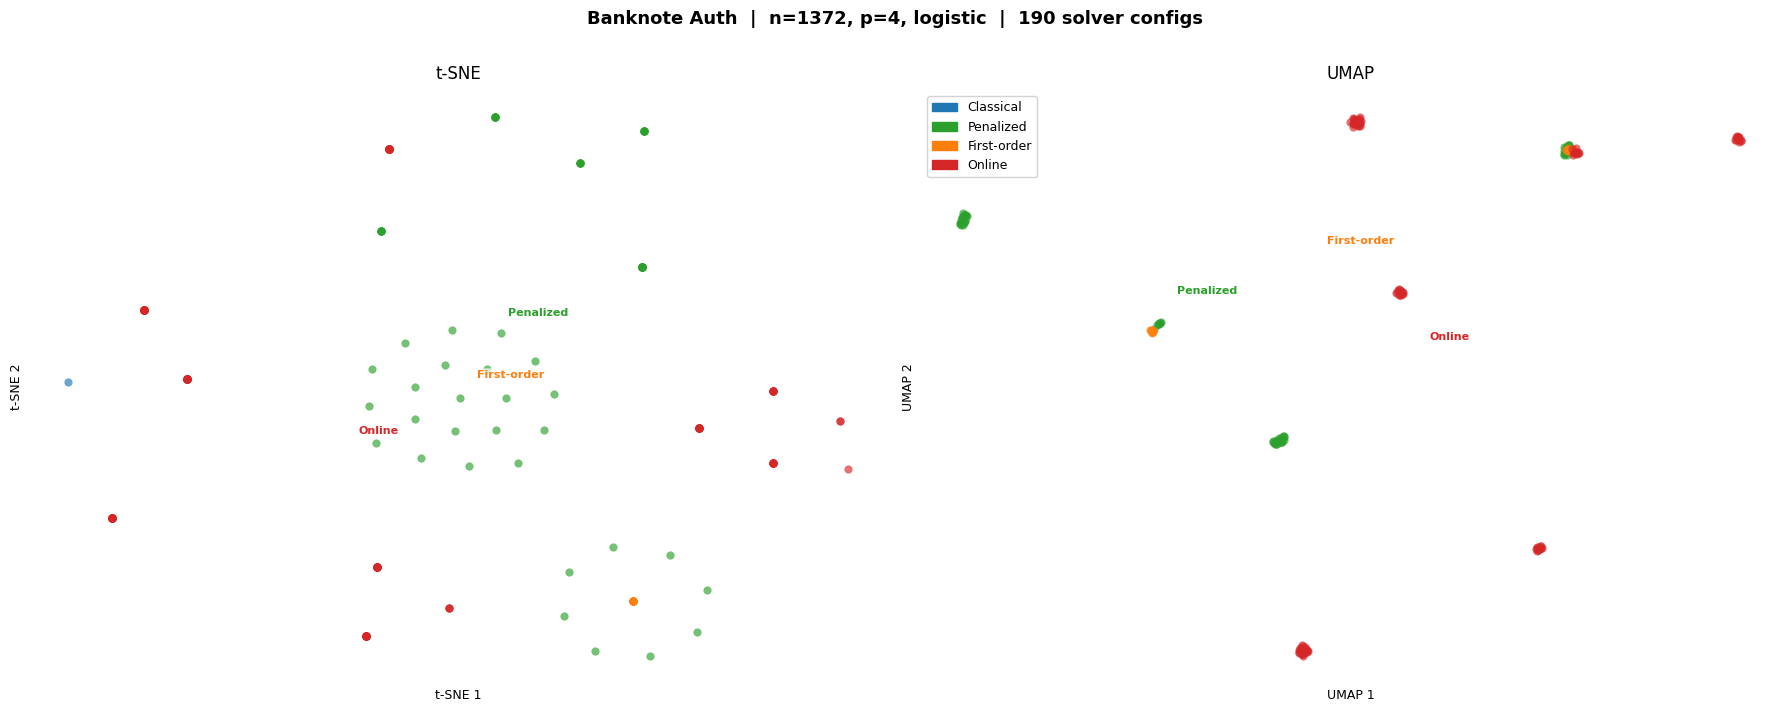

  Saved: fig_embed_Banknote_Auth.png


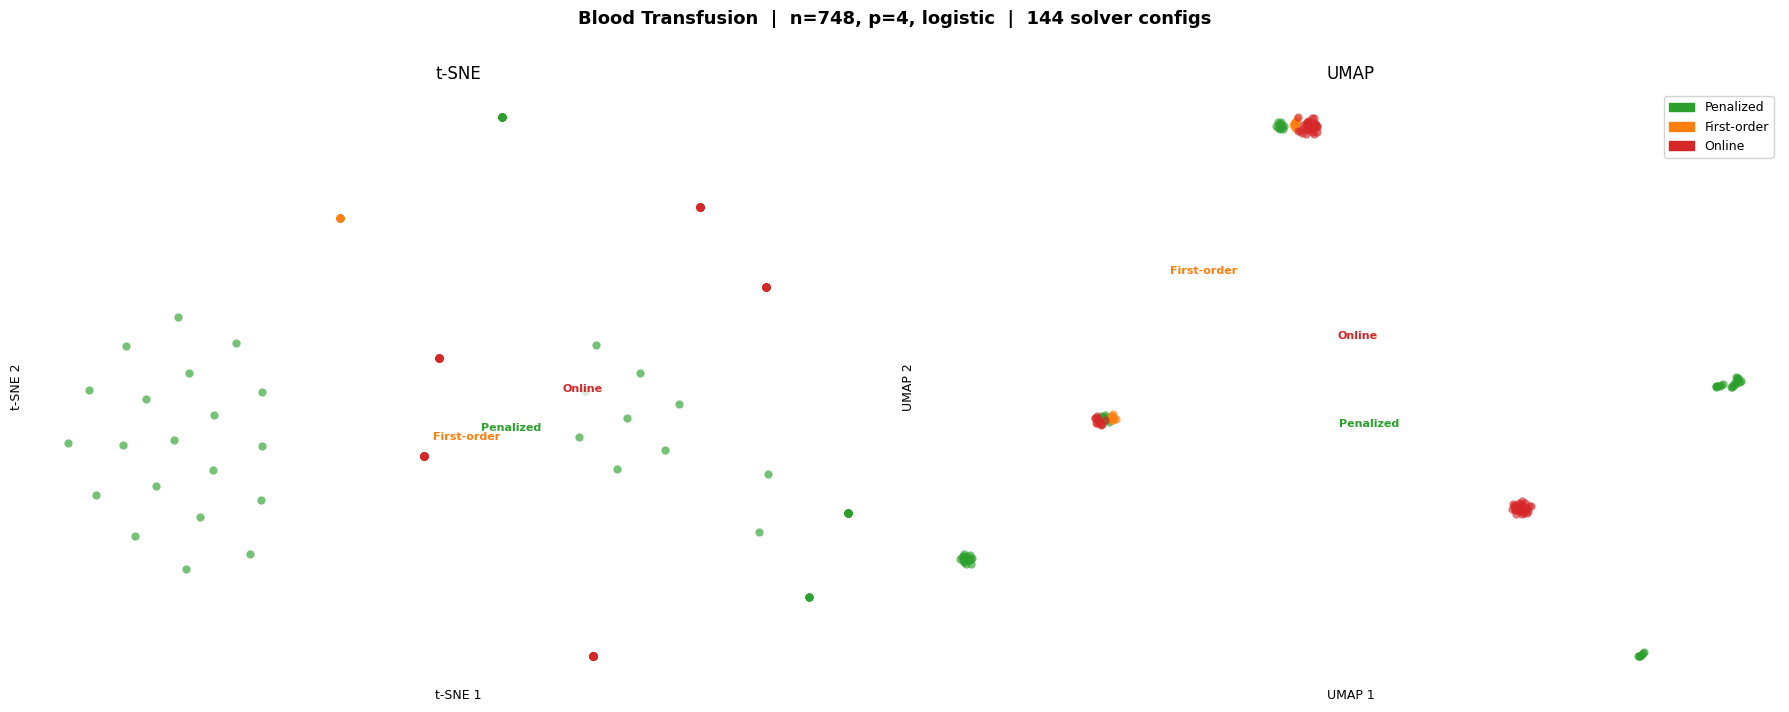

  Saved: fig_embed_Blood_Transfusion.png


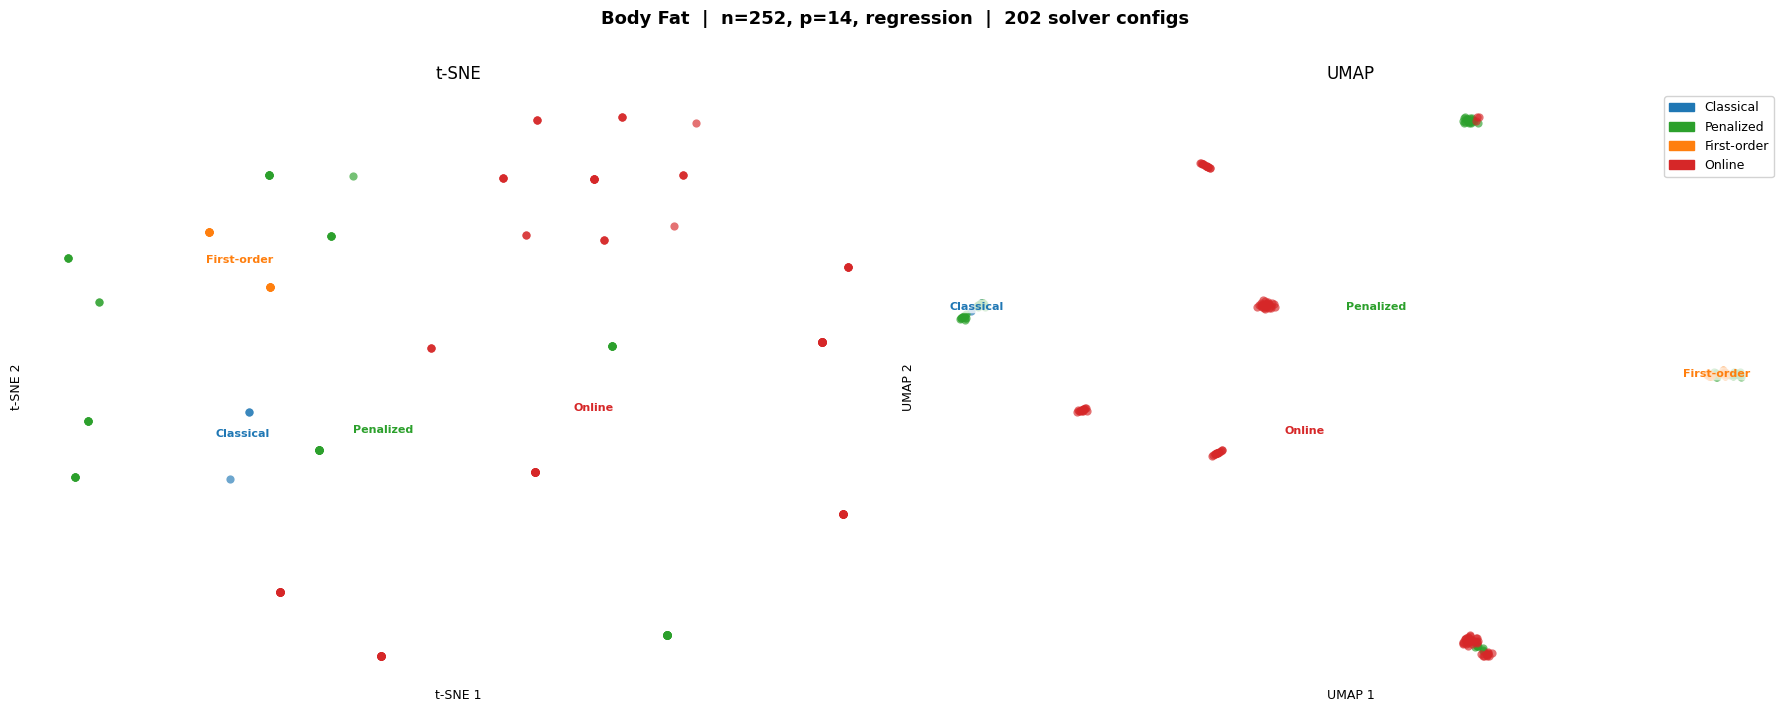

  Saved: fig_embed_Body_Fat.png


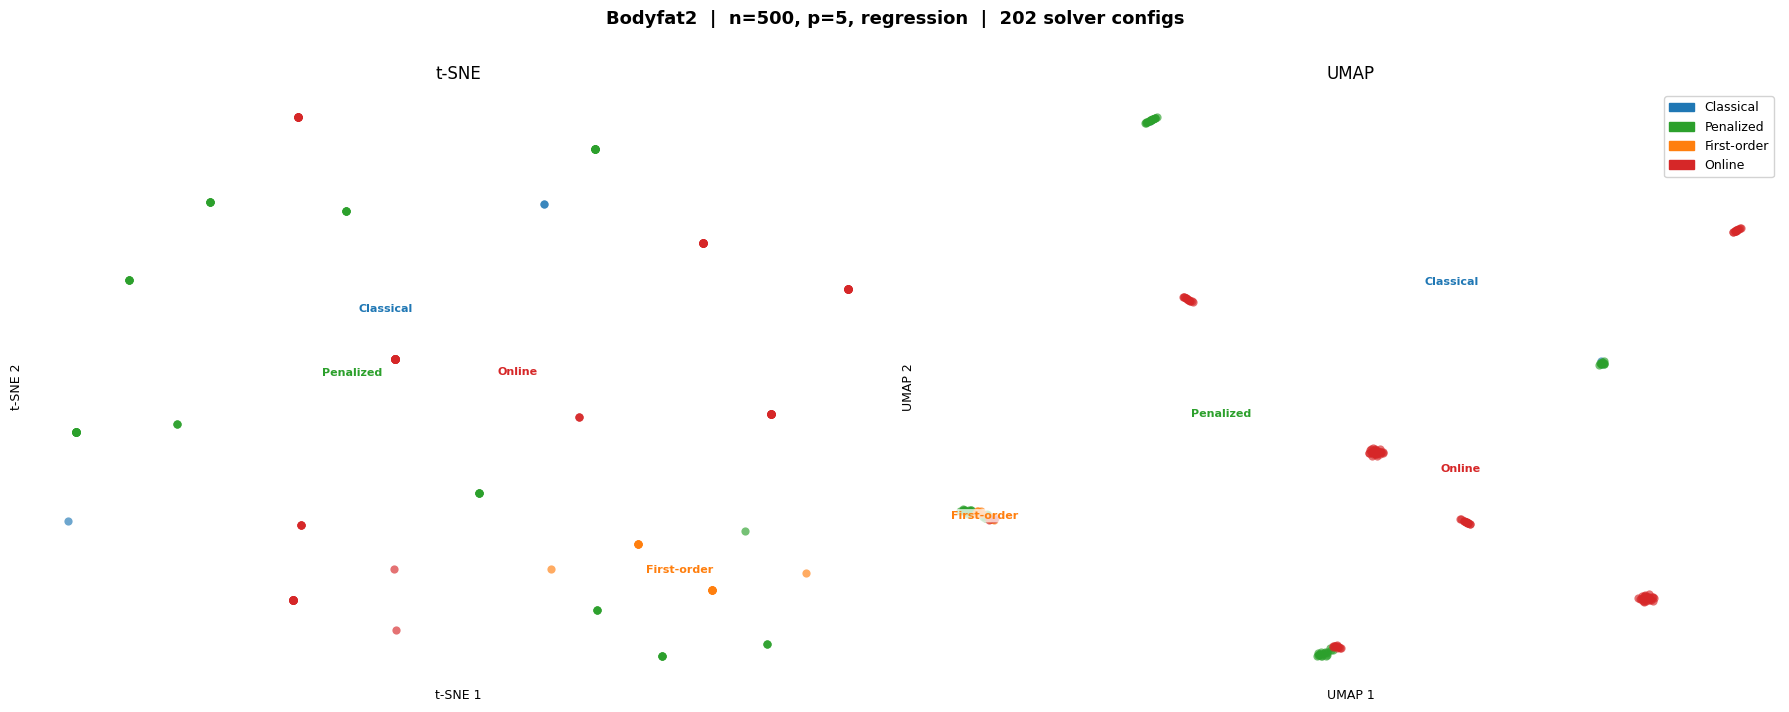

  Saved: fig_embed_Bodyfat2.png


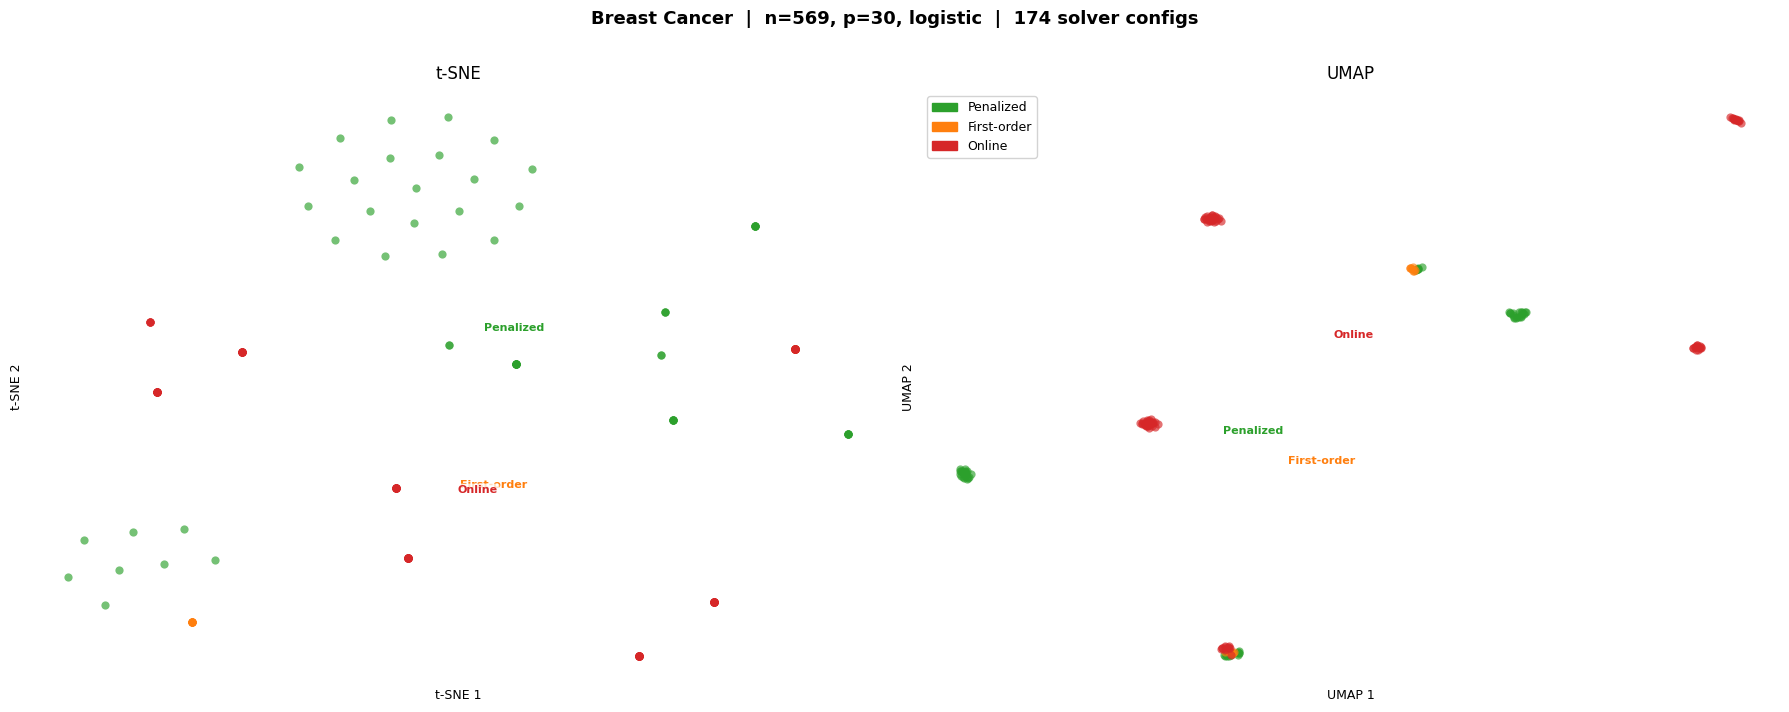

  Saved: fig_embed_Breast_Cancer.png


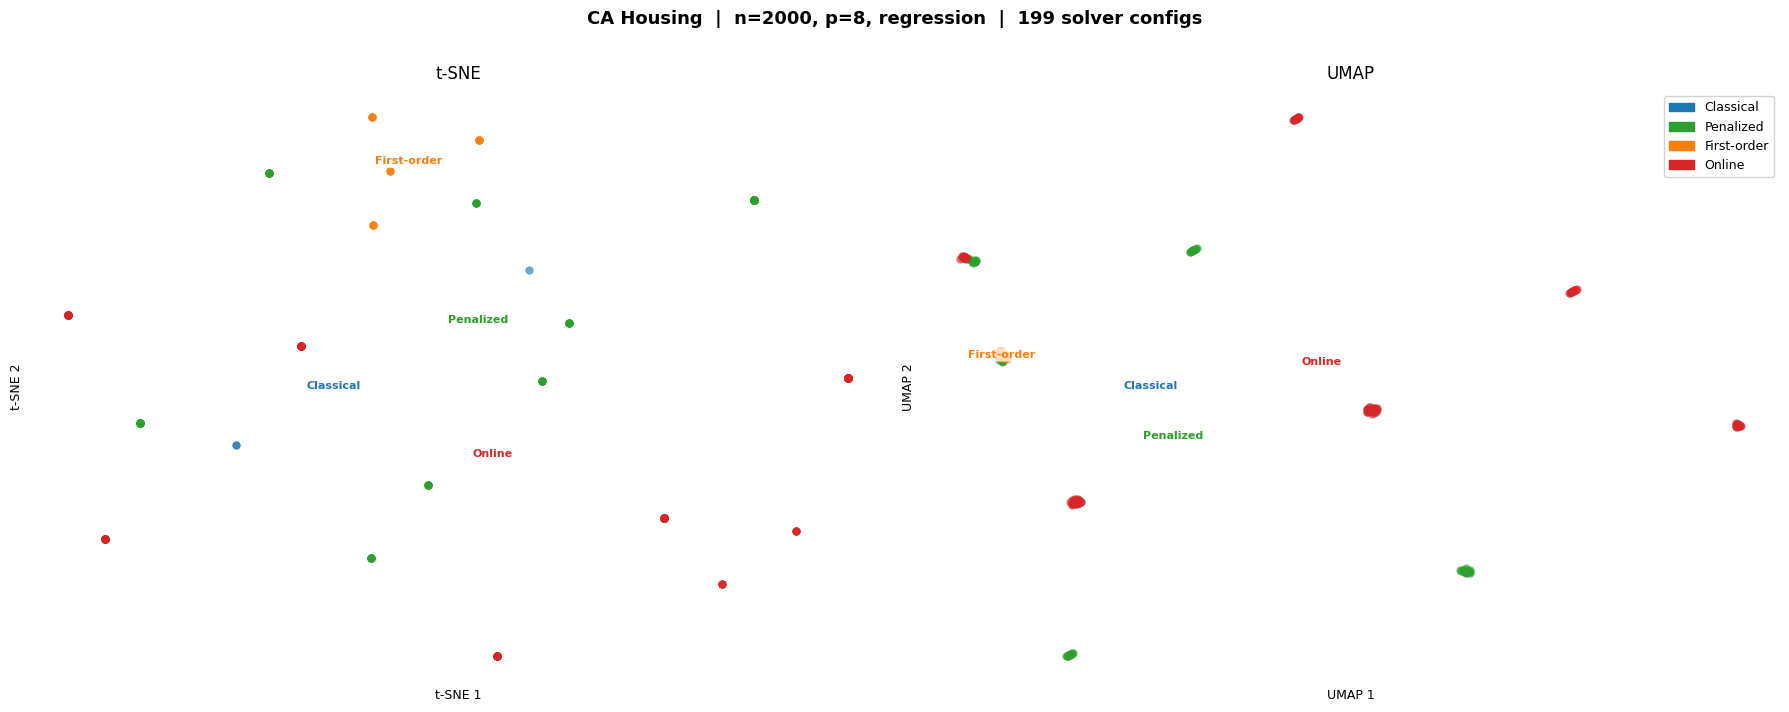

  Saved: fig_embed_CA_Housing.png


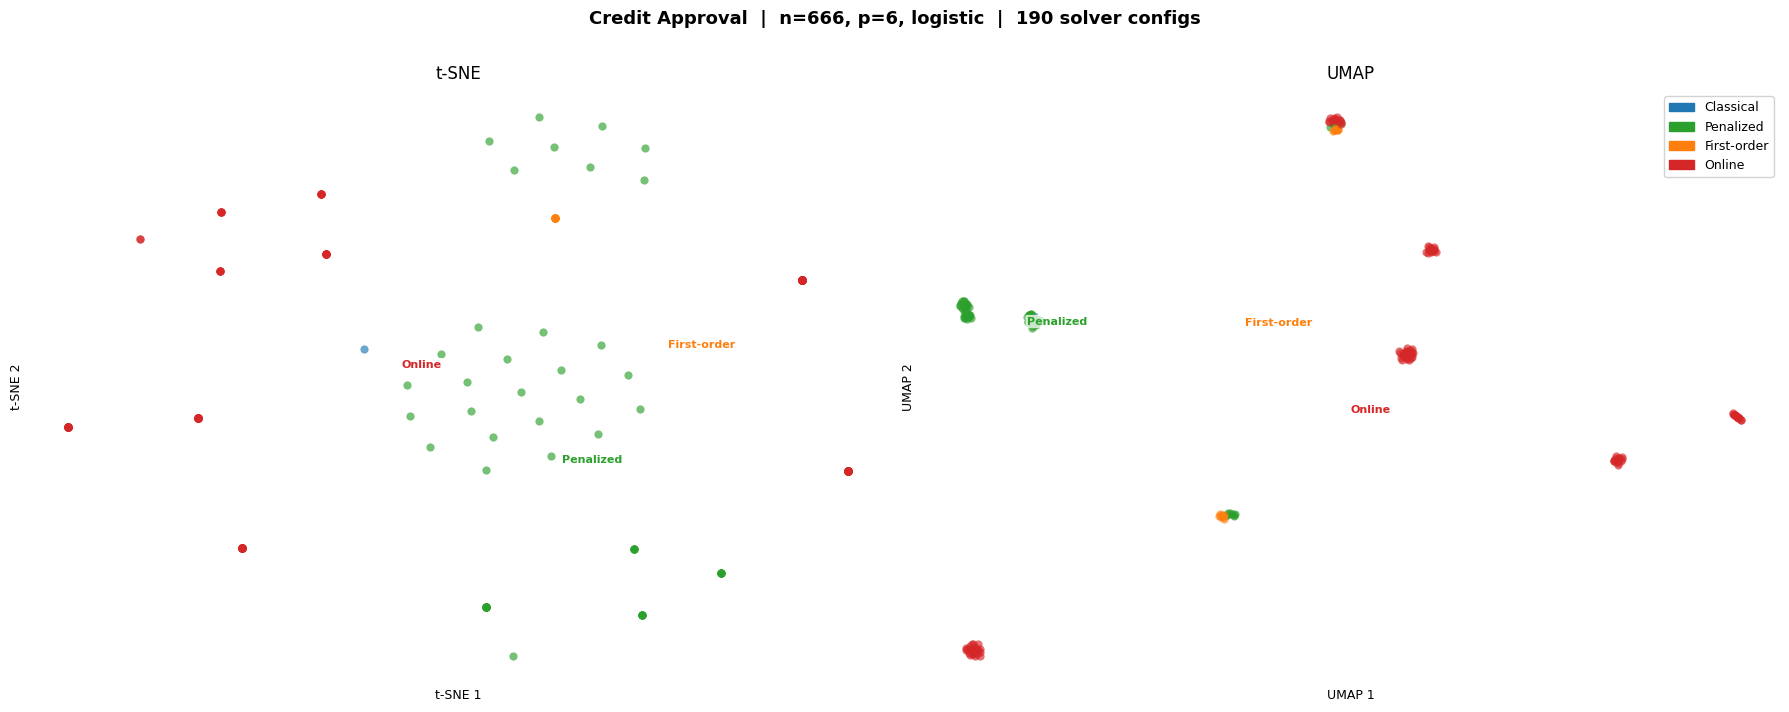

  Saved: fig_embed_Credit_Approval.png


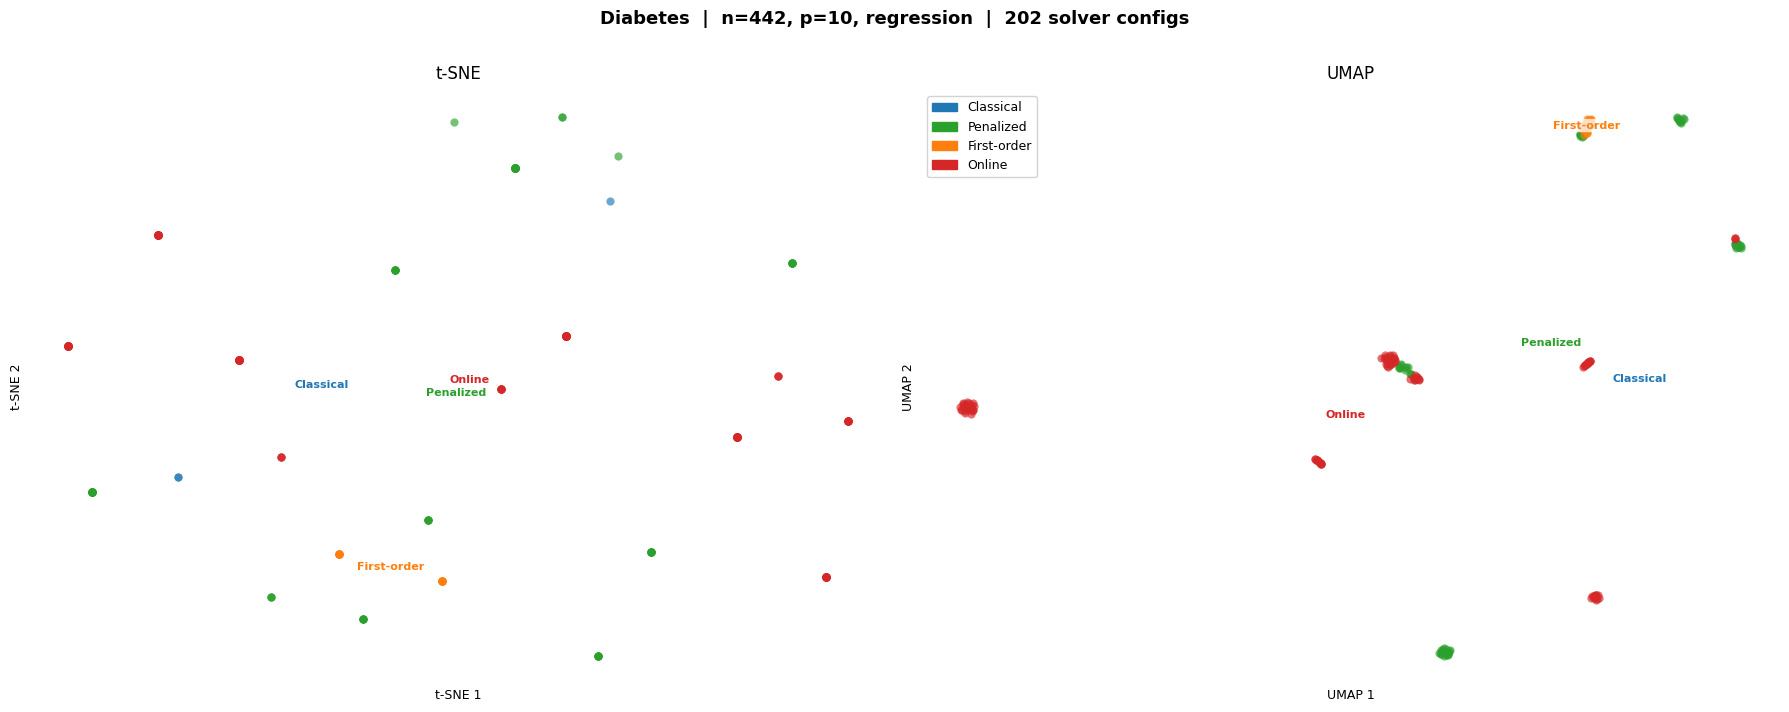

  Saved: fig_embed_Diabetes.png


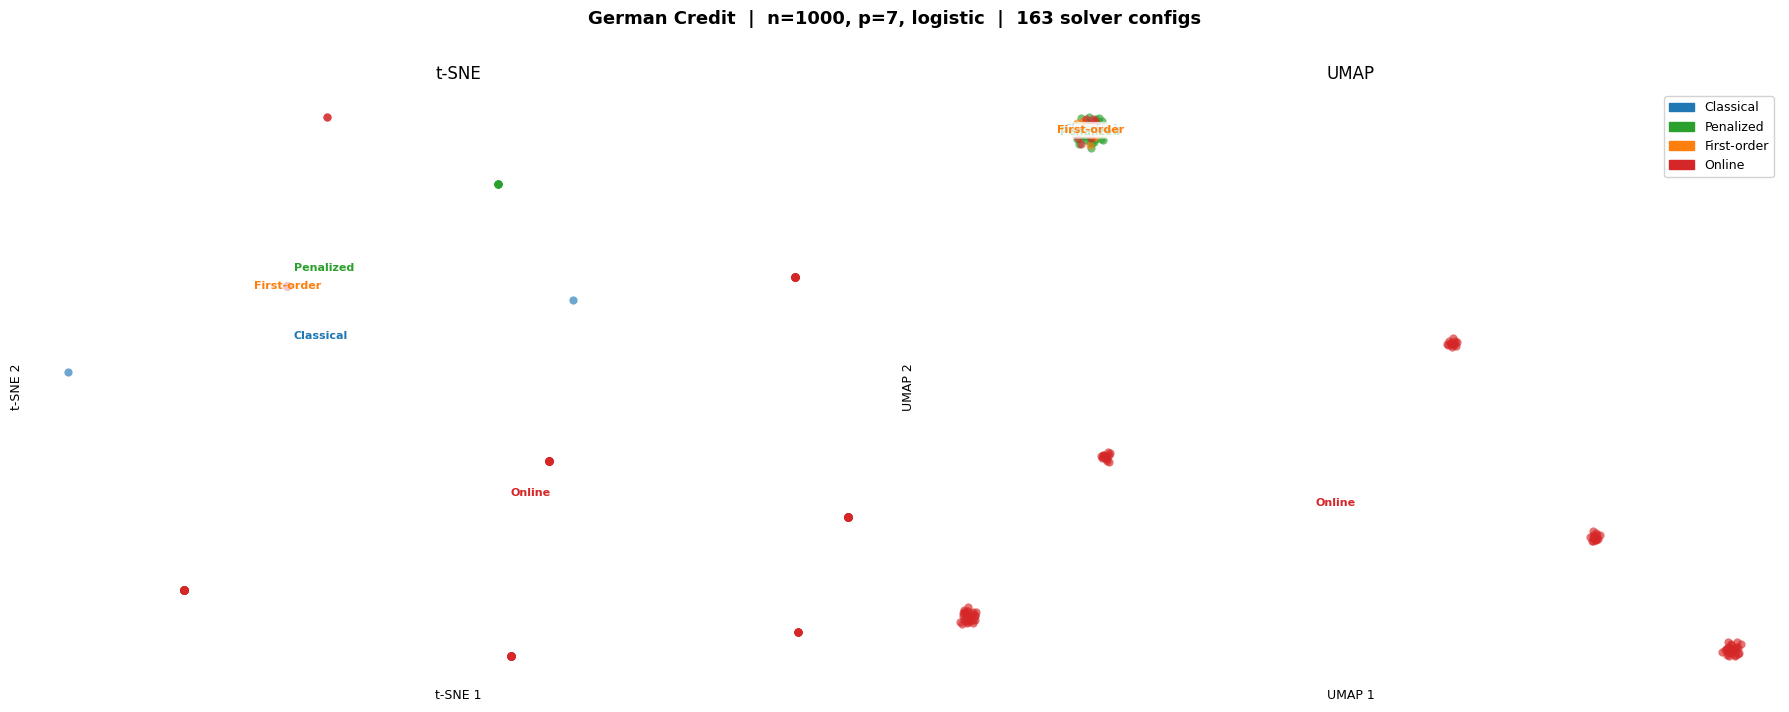

  Saved: fig_embed_German_Credit.png


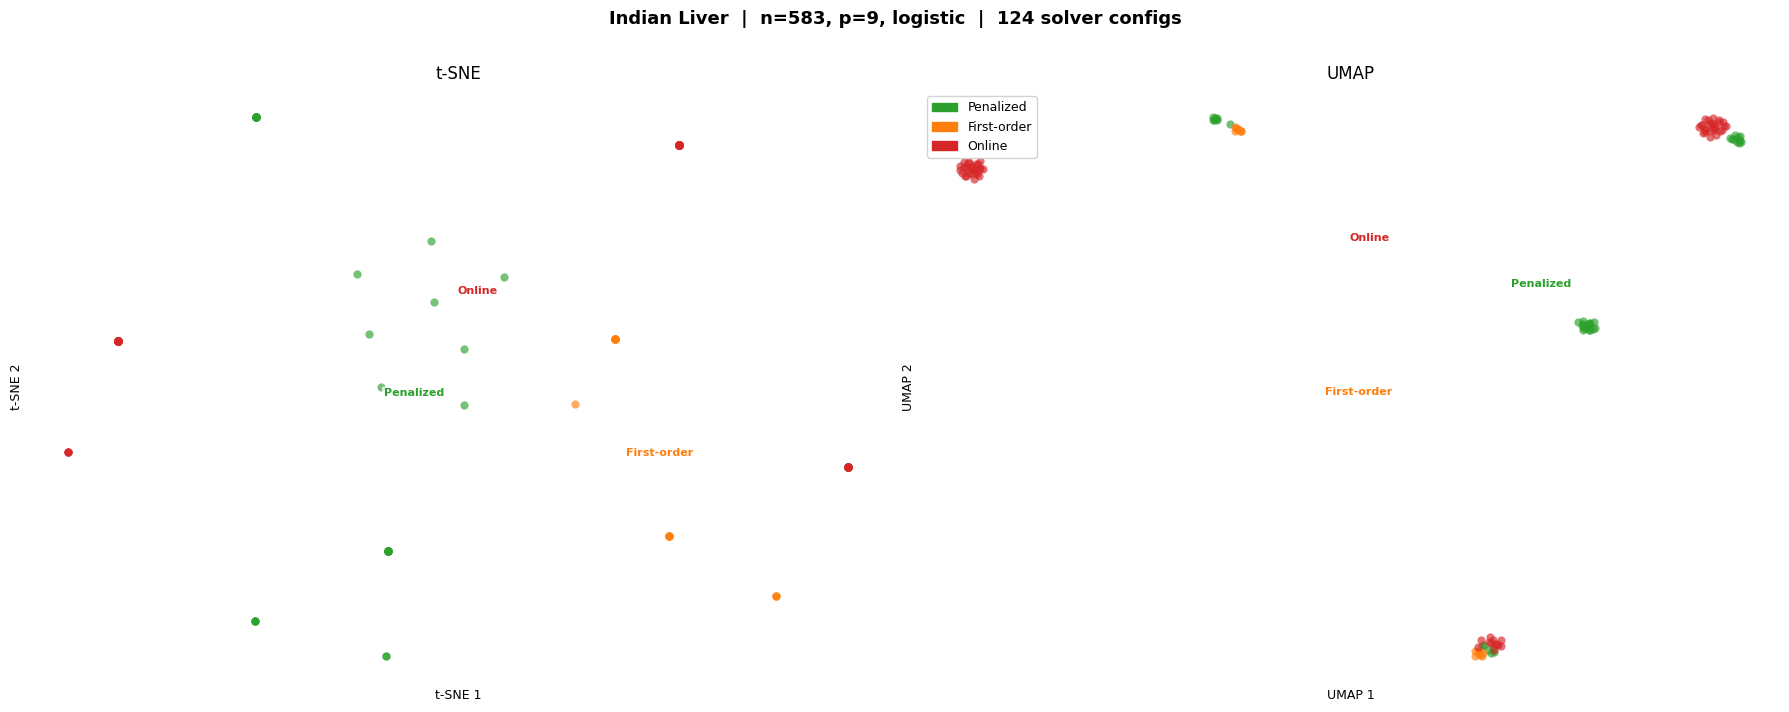

  Saved: fig_embed_Indian_Liver.png


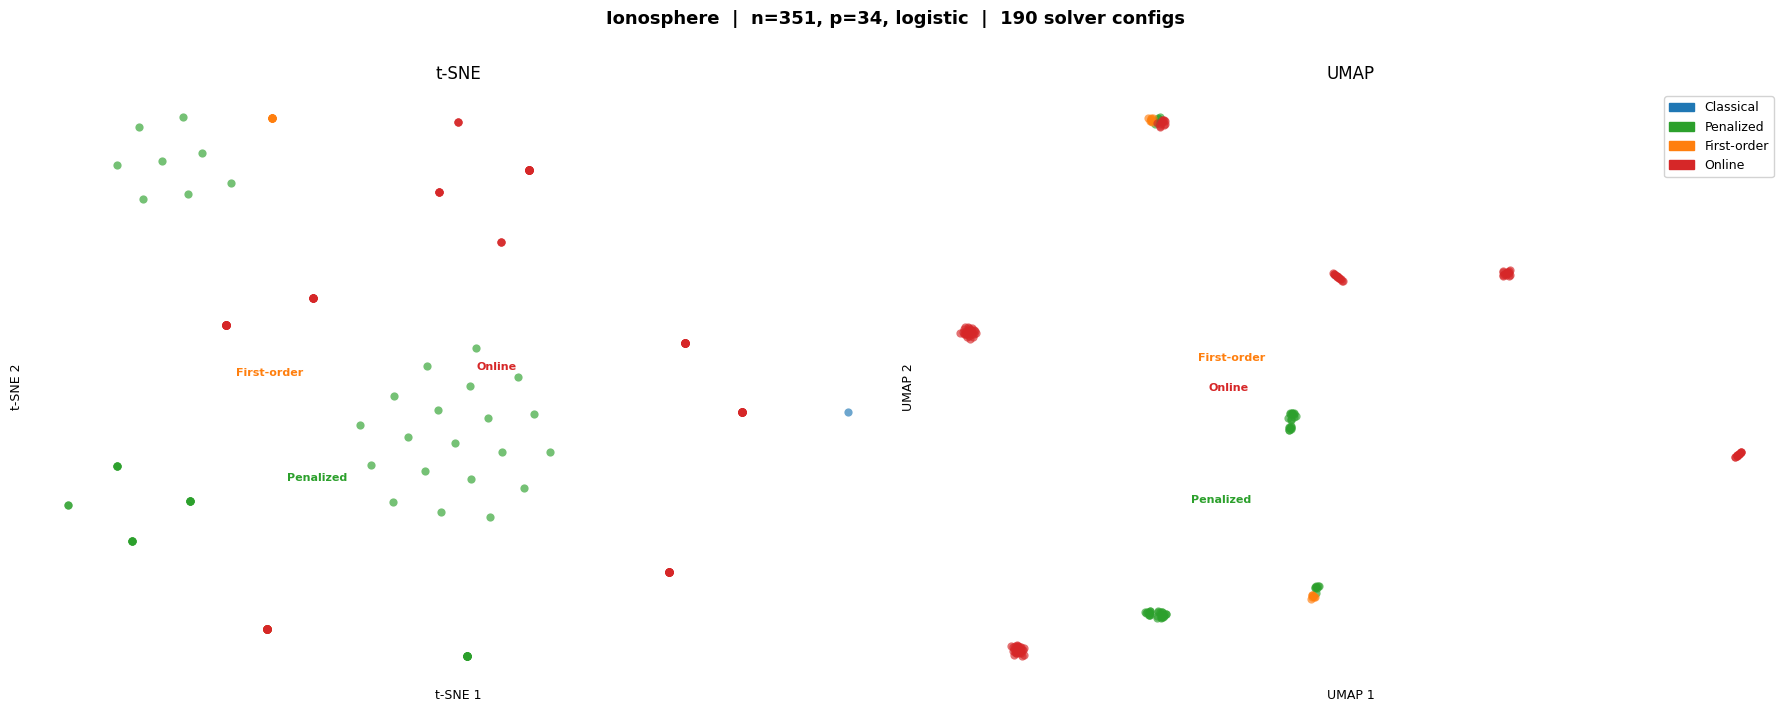

  Saved: fig_embed_Ionosphere.png


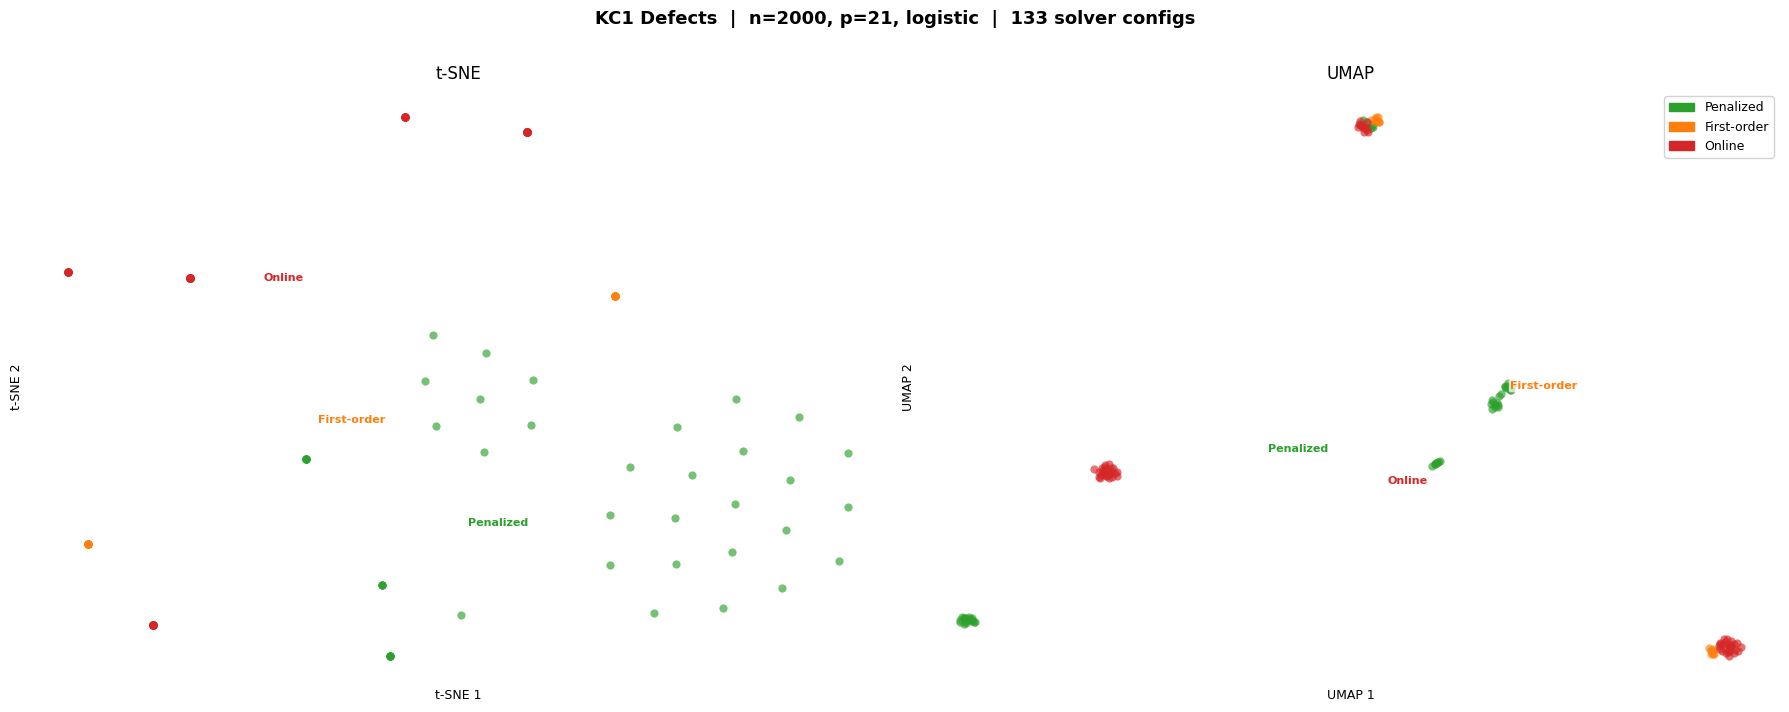

  Saved: fig_embed_KC1_Defects.png


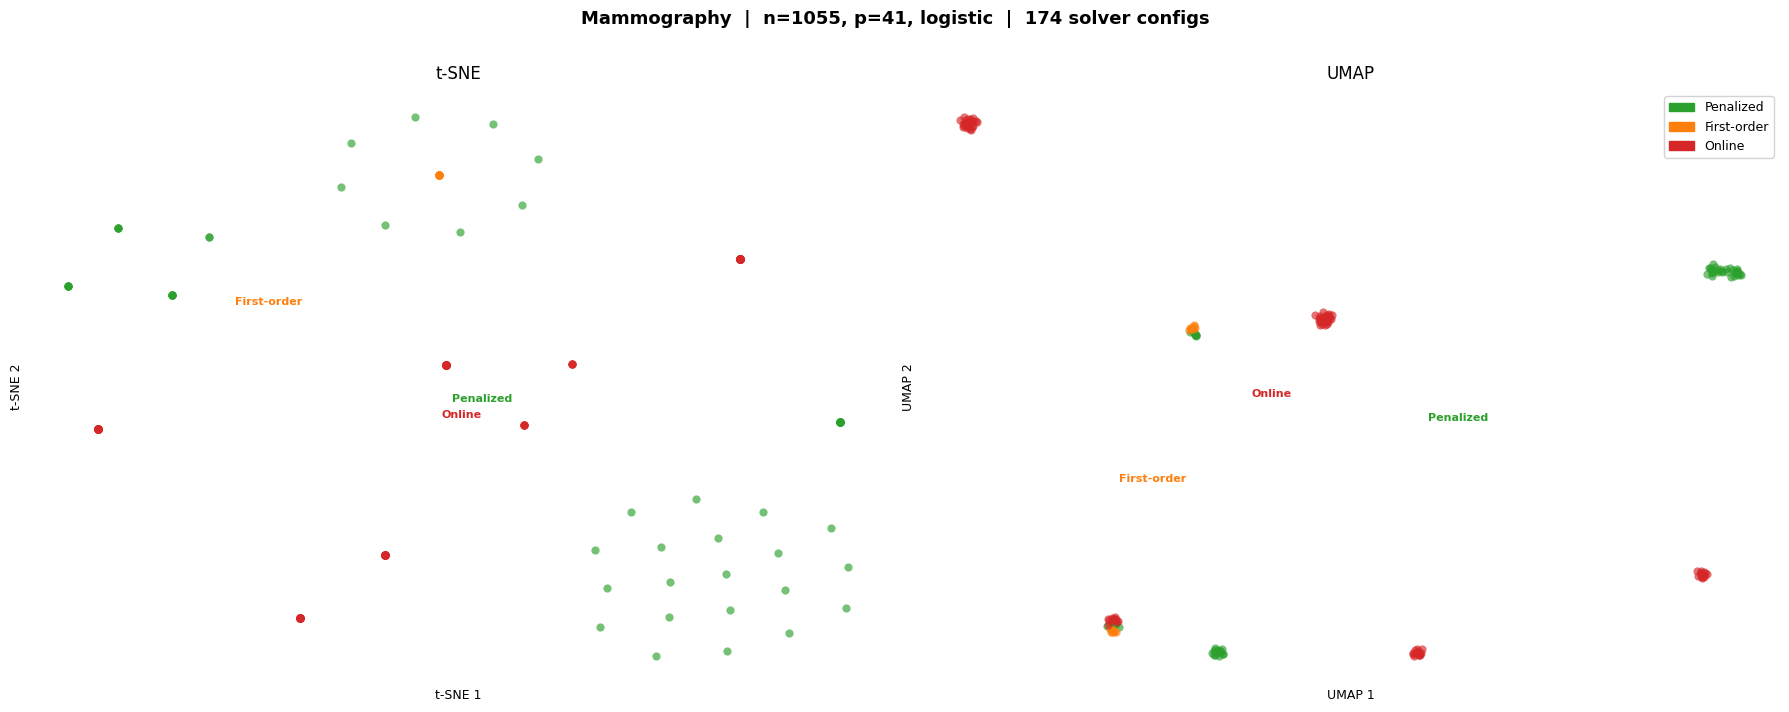

  Saved: fig_embed_Mammography.png


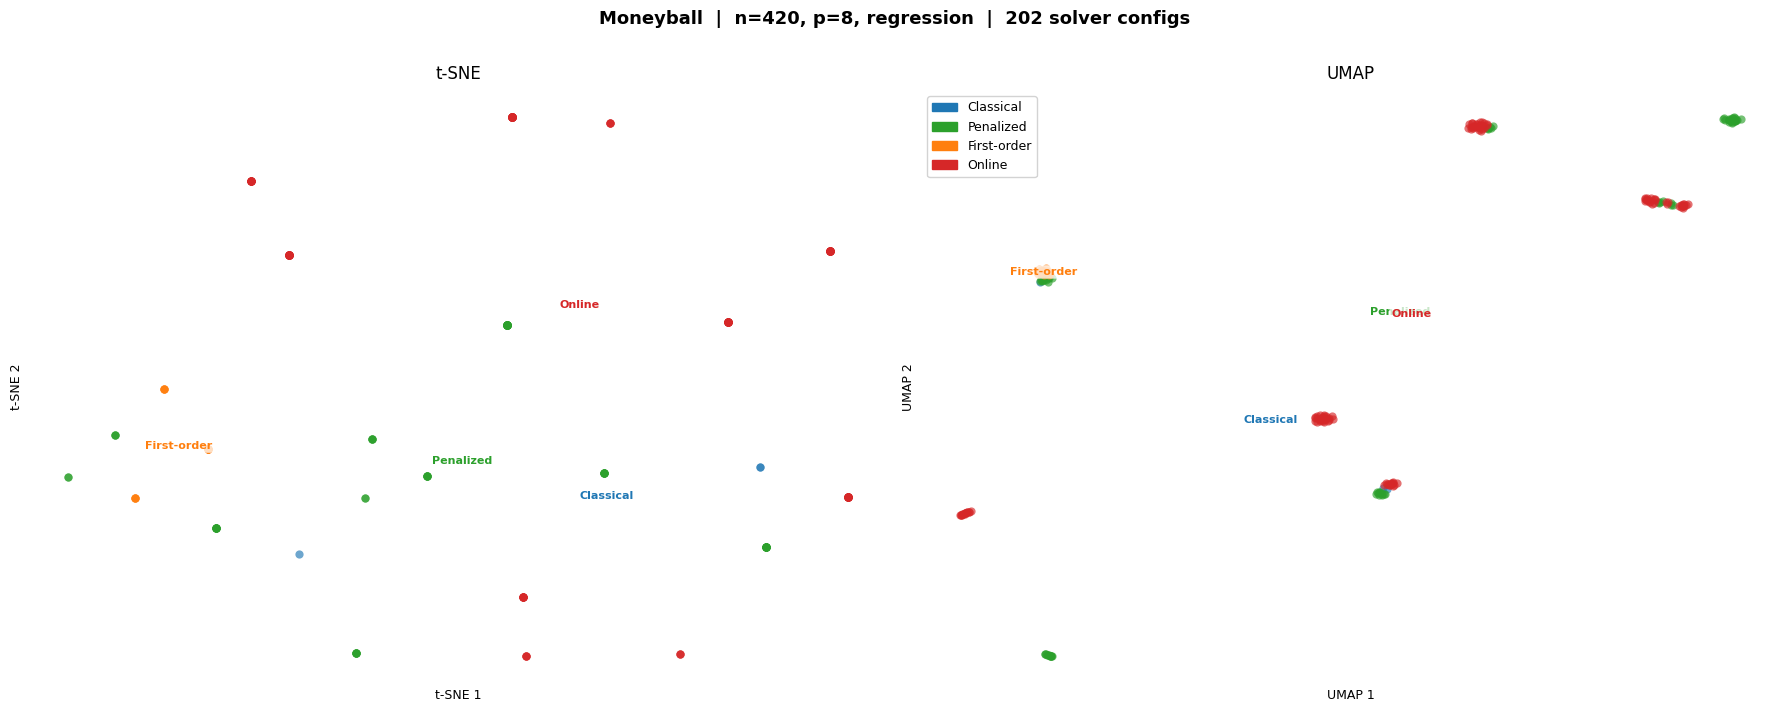

  Saved: fig_embed_Moneyball.png


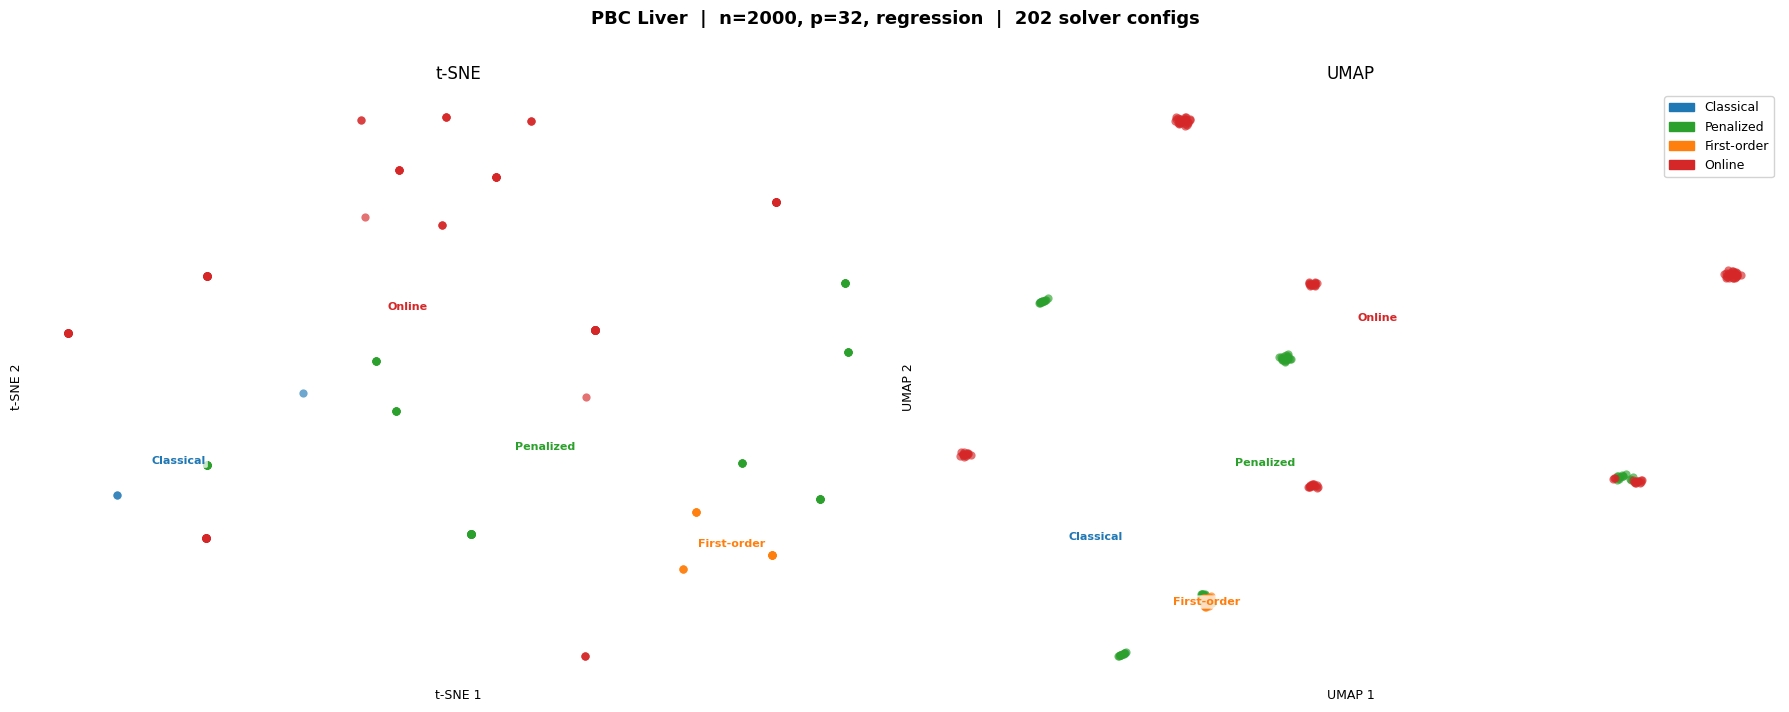

  Saved: fig_embed_PBC_Liver.png


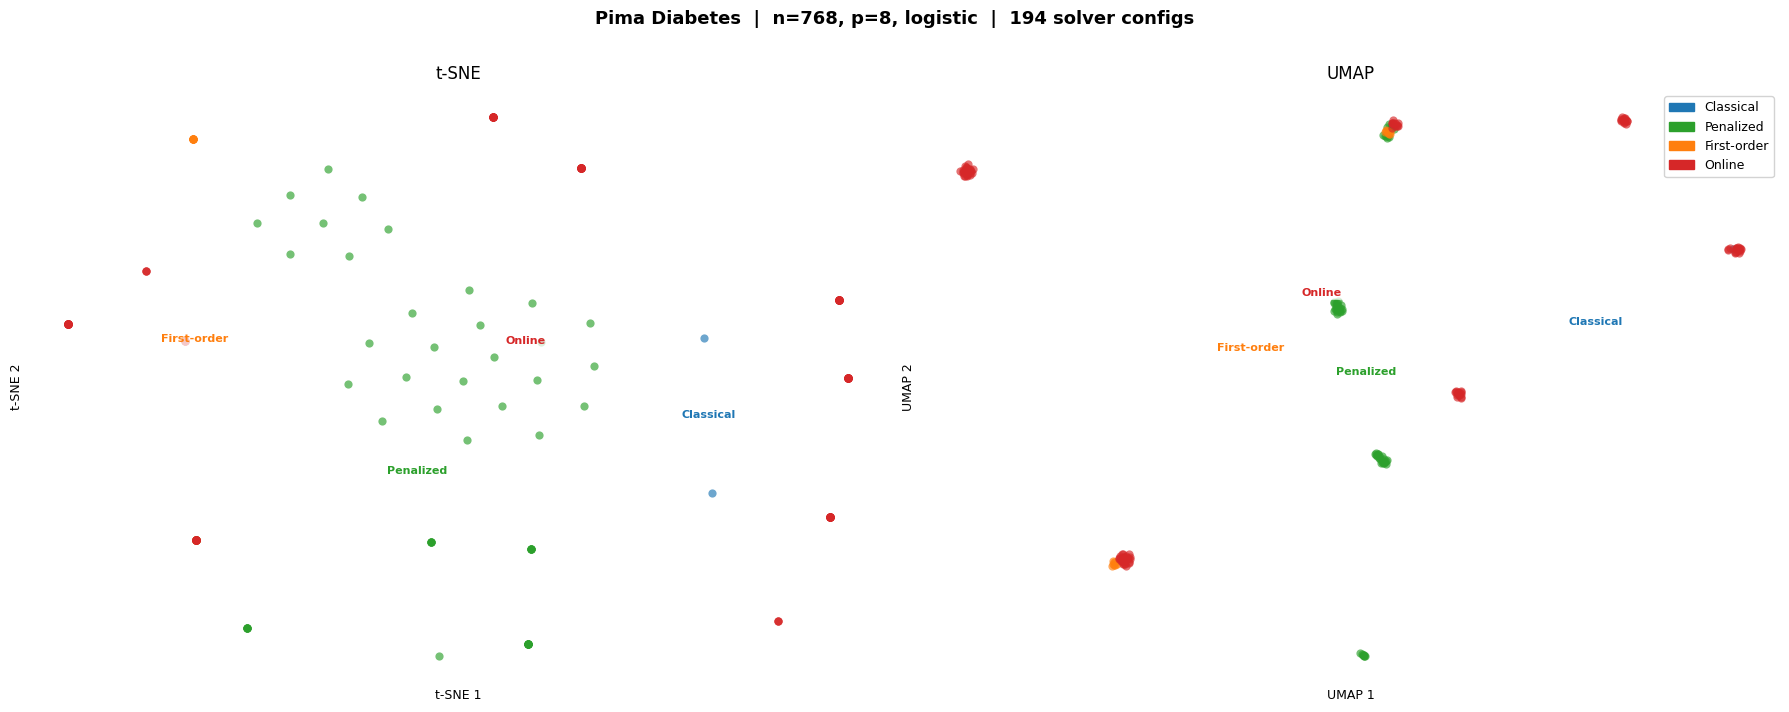

  Saved: fig_embed_Pima_Diabetes.png


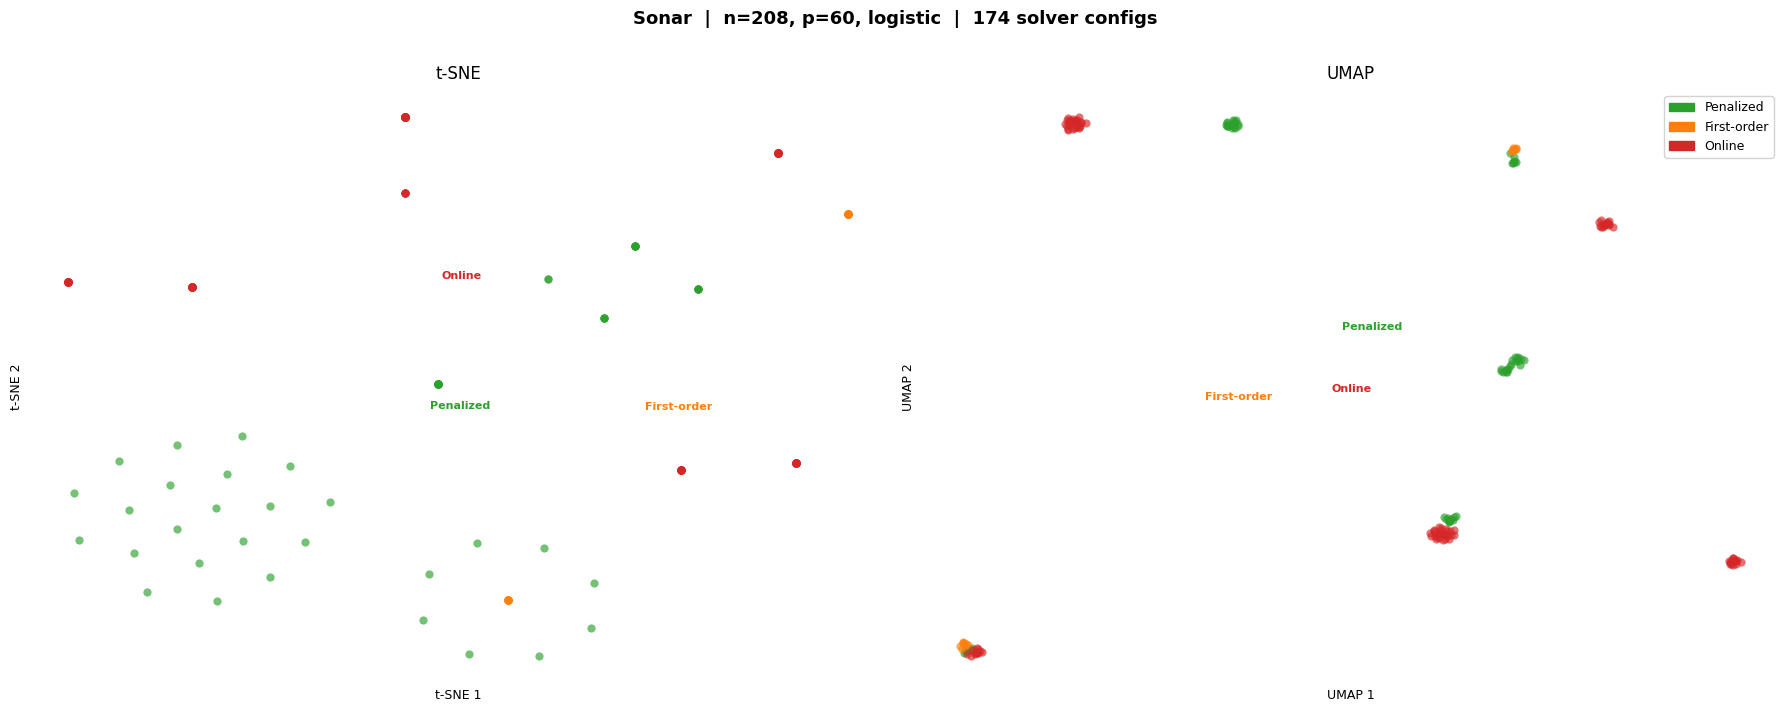

  Saved: fig_embed_Sonar.png


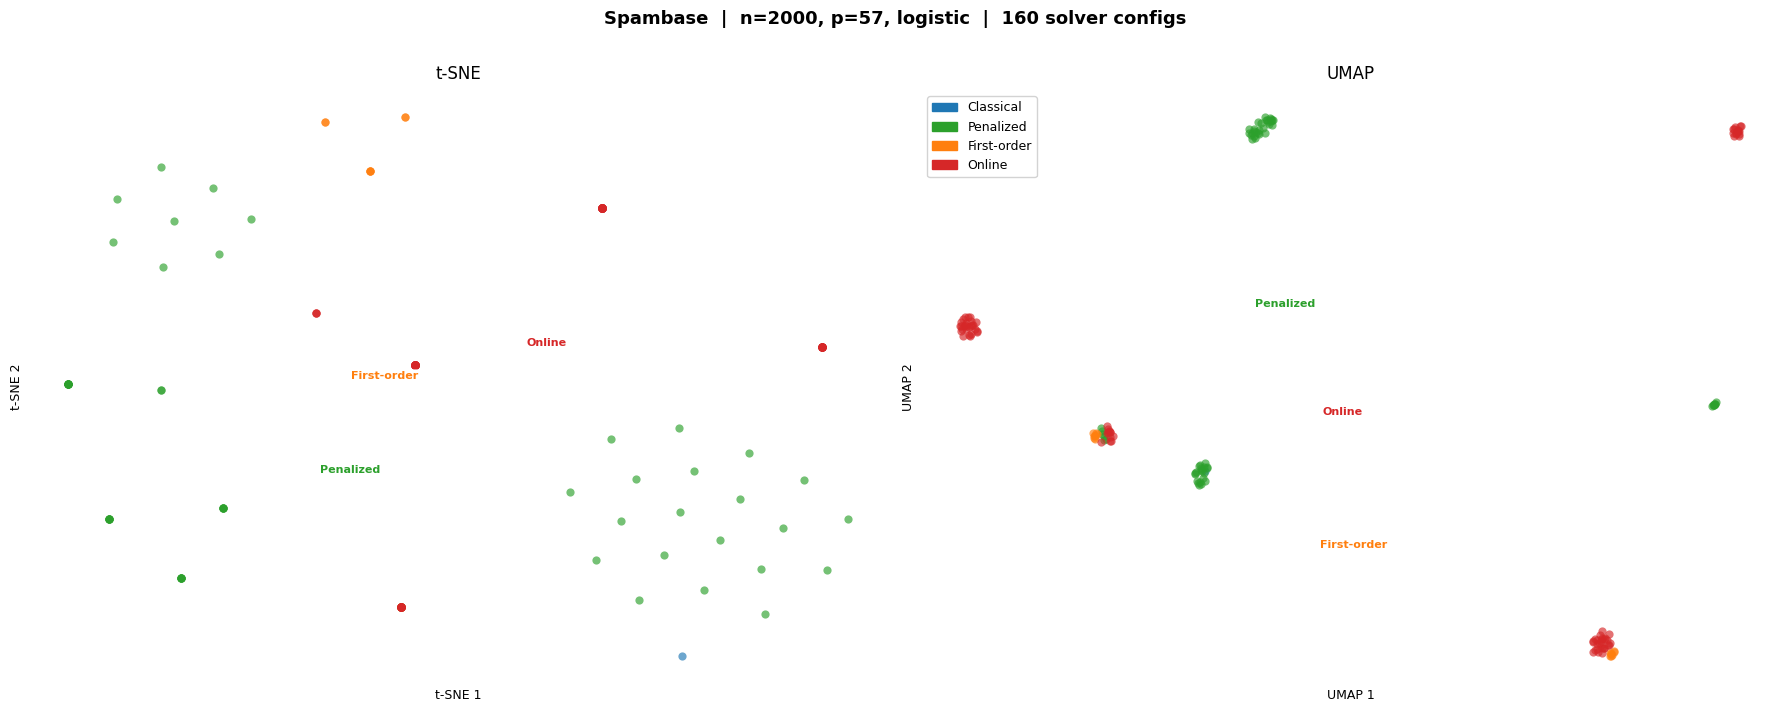

  Saved: fig_embed_Spambase.png


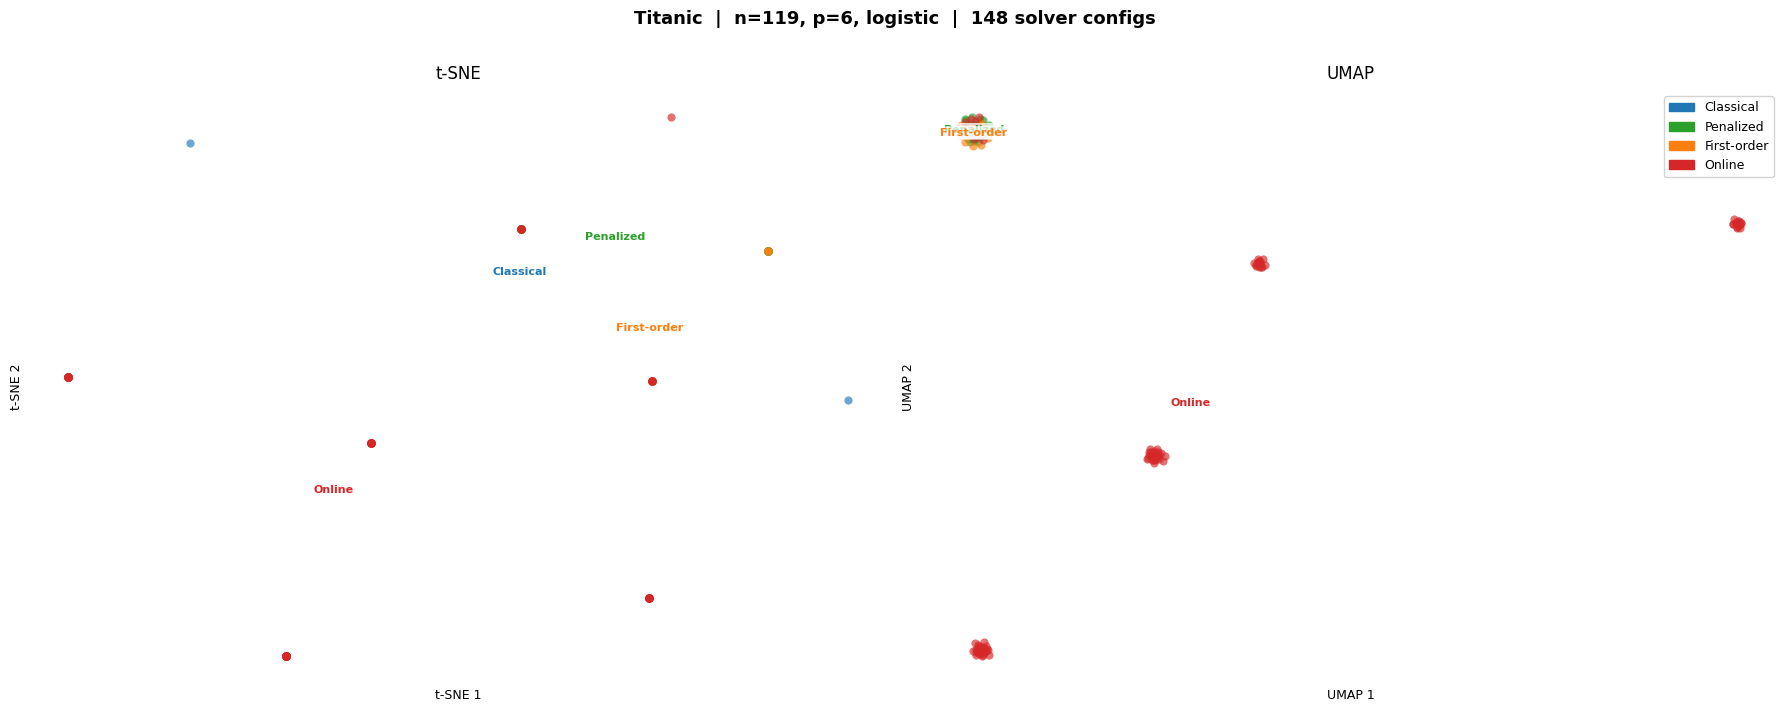

  Saved: fig_embed_Titanic.png


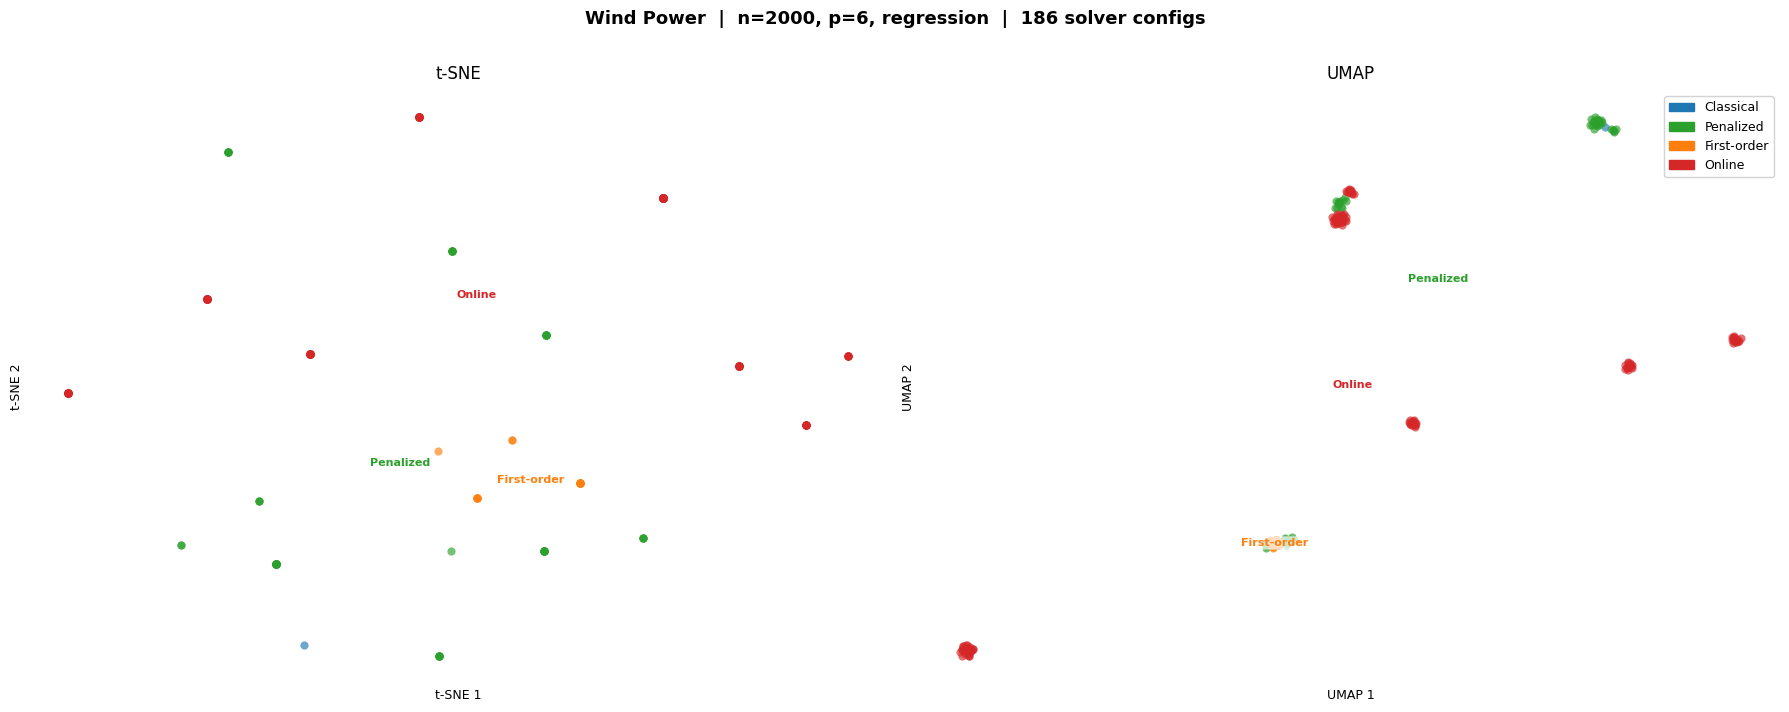

  Saved: fig_embed_Wind_Power.png


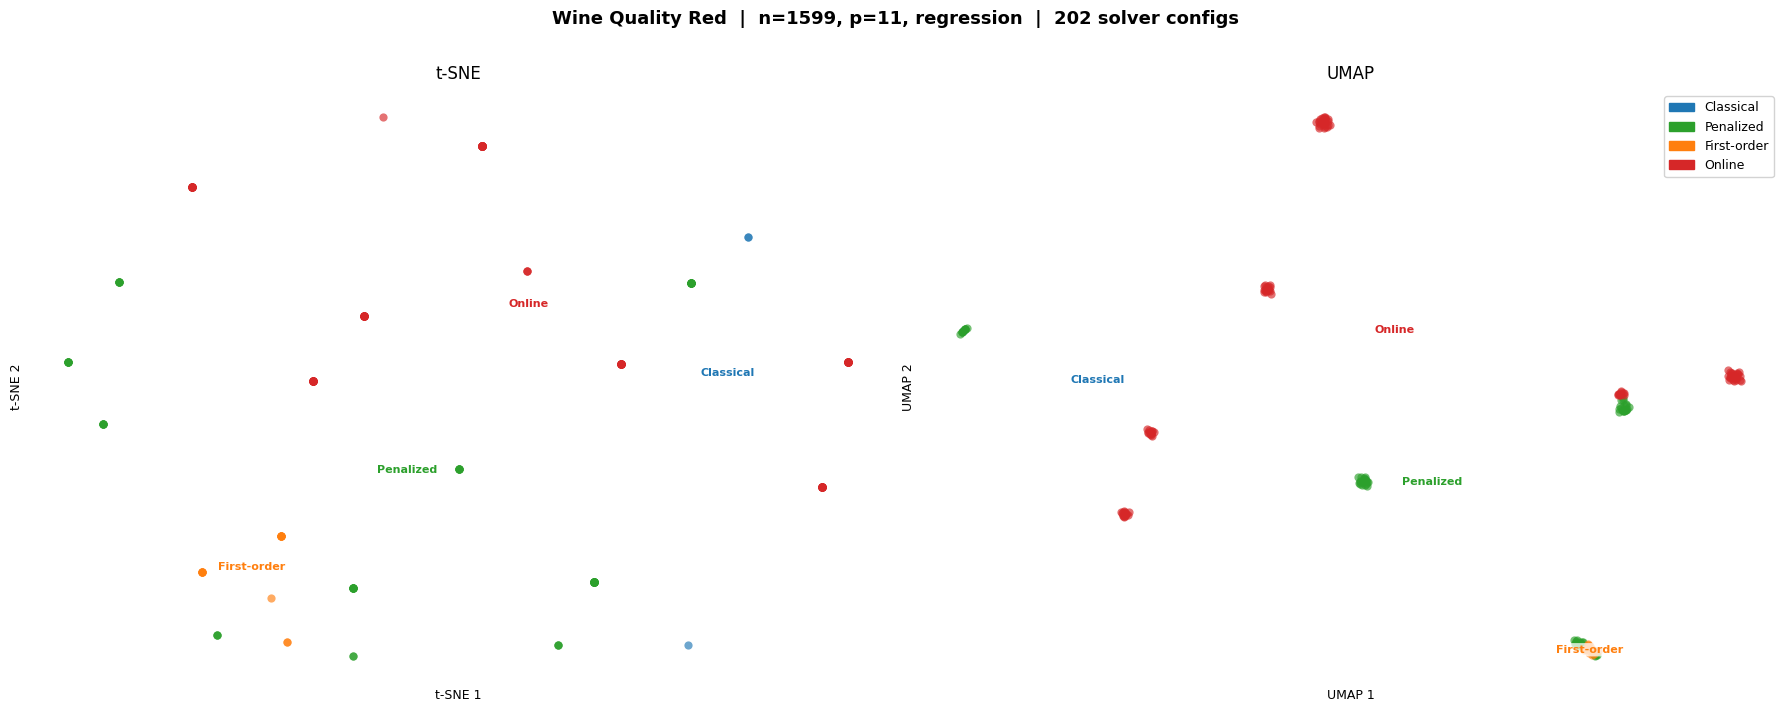

  Saved: fig_embed_Wine_Quality_Red.png

Total embedding figures: 24


In [7]:
embed_figs = []

for ds_name, grp in df_clean.groupby('dataset'):
    n_pts = len(grp)
    if n_pts < 5:
        print(f"SKIP {ds_name}: only {n_pts} clean points"); continue

    p        = int(grp['p'].iloc[0])
    betas    = np.vstack(grp['beta'].values)
    families = grp['family'].values

    # ── t-SNE ─────────────────────────────────────────────────────────────────
    perp    = min(30, max(5, n_pts // 5))
    tsne_kw = {_TSNE_ITER_KW: 1000}
    xy_tsne = TSNE(n_components=2, perplexity=perp, init='pca',
                   random_state=42, **tsne_kw).fit_transform(betas)

    # ── UMAP ──────────────────────────────────────────────────────────────────
    nn      = min(15, max(3, n_pts // 6))
    xy_umap = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1,
                        random_state=42).fit_transform(betas)

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ds_meta   = datasets[ds_name]
    fig.suptitle(
        f"{ds_name}  |  n={ds_meta['X'].shape[0]}, p={p}, {ds_meta['kind']}"
        f"  |  {n_pts} solver configs",
        fontsize=13, fontweight='bold', y=1.01,
    )

    for ax, coords, method in zip(axes, [xy_tsne, xy_umap], ['t-SNE', 'UMAP']):
        for fam, color in FAMILY_COLORS.items():
            m = families == fam
            if m.sum() == 0:
                continue
            ax.scatter(coords[m, 0], coords[m, 1], c=color,
                       label=fam, alpha=0.65, s=35, linewidths=0)

        # Annotate family centroids
        for fam, color in FAMILY_COLORS.items():
            m = families == fam
            if m.sum() < 2:
                continue
            cx = coords[m, 0].mean()
            cy = coords[m, 1].mean()
            ax.text(cx, cy, fam, ha='center', va='center', fontsize=8,
                    fontweight='bold', color=color,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              alpha=0.75, ec='none'))

        ax.set_title(method, fontsize=12, pad=8)
        ax.set_xlabel(f'{method} 1', fontsize=9)
        ax.set_ylabel(f'{method} 2', fontsize=9)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for sp in ax.spines.values():
            sp.set_visible(False)

    handles = [mpatches.Patch(color=c, label=f)
               for f, c in FAMILY_COLORS.items() if f in families]
    axes[1].legend(handles=handles, loc='best', framealpha=0.85, fontsize=9)

    plt.tight_layout()
    safe  = (ds_name.replace(' ','_').replace('/','_')
             .replace('(','').replace(')',''))
    fname = f'fig_embed_{safe}.png'
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    embed_figs.append(fname)
    print(f'  Saved: {fname}')

print(f"\nTotal embedding figures: {len(embed_figs)}")


## Section 7 — Coefficient Norm by Solver Family

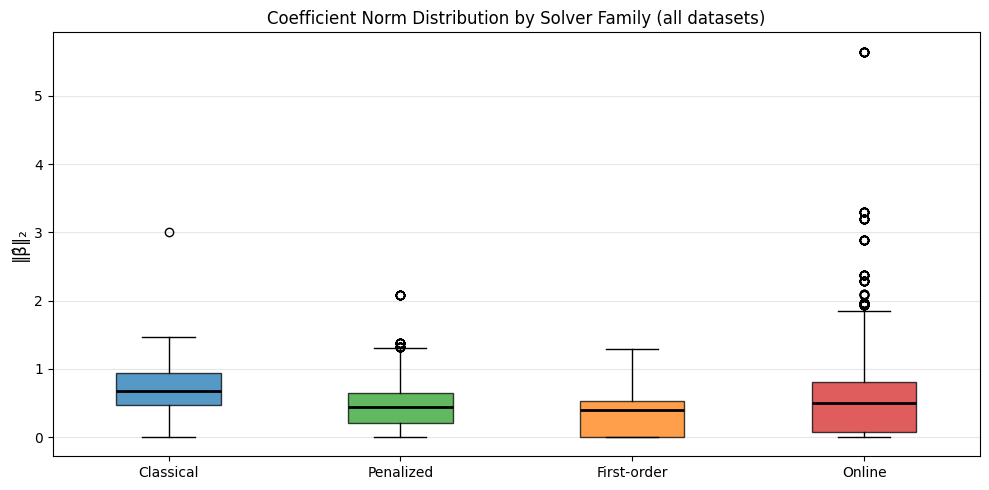

Saved: fig_norm_boxplot.png


In [8]:
fam_order = ['Classical', 'Penalized', 'First-order', 'Online']
data_bp   = [df_clean[df_clean['family'] == f]['bnorm'].dropna().values
             for f in fam_order]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_bp, labels=fam_order, patch_artist=True, notch=False,
                medianprops=dict(color='k', lw=2))
for patch, fam in zip(bp['boxes'], fam_order):
    patch.set_facecolor(FAMILY_COLORS[fam])
    patch.set_alpha(0.75)

ax.set_ylabel('‖β̂‖₂', fontsize=12)
ax.set_title('Coefficient Norm Distribution by Solver Family (all datasets)',
             fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_norm_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: fig_norm_boxplot.png")


## Section 8 — Summary

In [9]:
print(f"Datasets loaded:     {len(datasets)}")
print(f"Solver configs:      {len(SOLVER_CONFIGS)}")
print(f"Total arena runs:    {len(df_all)}")
print(f"After outlier filter:{len(df_clean)}")
print()
print("Success rate by family:")
for fam in ['Classical', 'Penalized', 'First-order', 'Online']:
    sub = df_all[df_all['family'] == fam]
    if len(sub) == 0: continue
    pct = 100 * sub['ok'].mean()
    print(f"  {fam:12s}: {sub['ok'].sum():5d}/{len(sub):5d}  ({pct:.1f}%)")
print()
print("Mean ‖β̂‖₂ after filtering:")
for fam in ['Classical', 'Penalized', 'First-order', 'Online']:
    sub = df_clean[df_clean['family'] == fam]['bnorm']
    if len(sub) == 0: continue
    print(f"  {fam:12s}: mean={sub.mean():.4f}  median={sub.median():.4f}")


Datasets loaded:     24
Solver configs:      202
Total arena runs:    4744
After outlier filter:4359

Success rate by family:
  Classical   :    59/   59  (100.0%)
  Penalized   :  1509/ 1565  (96.4%)
  First-order :   384/  384  (100.0%)
  Online      :  2736/ 2736  (100.0%)

Mean ‖β̂‖₂ after filtering:
  Classical   : mean=0.7628  median=0.6811
  Penalized   : mean=0.4636  median=0.4469
  First-order : mean=0.3515  median=0.3980
  Online      : mean=0.6425  median=0.4994
